## First Mission

Growth Audit: Marketing claims our App Conversion Rate is ~78%. 

Task: Recalculate the conversion rate based on a stricter definition that aligns with sustainable economic behavior for the bank. Explain the discrepancy between your number and Marketing's.

Execution Breakdown:
- Reverse-engineer Marketing`s 78% and document premisses used
- Recreate a more accurate way of evaluate this metric
- Compare both premisses and describe why is important to use the second method instead of the Marketing method 

##### Imports

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("fraud_prevention_data.csv")
df.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,NZL,FAILED,1992,GB,False


##### Treat Country Columns

In [26]:
# Import ISO country code table

country_codes = pd.read_excel("CountryCodesTable_ISO3166.xlsx")
country_codes["Numeric_3"] = (
    country_codes["Numeric"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)

country_codes.head()

,Country,Alpha-2-code,Alpha-3-code,Numeric,Numeric_3
0,Afghanistan,AF,AFG,4,004
1,Albania,AL,ALB,8,008
2,Algeria,DZ,DZA,12,012
3,American Samoa,AS,ASM,16,016
4,Andorra,AD,AND,20,020


In [27]:
## Creating From/To Dictionary

iso2_to_country_name = dict(
    zip(country_codes["Alpha-2-code"], country_codes["Country"])
)

iso3_to_country_name = dict(
    zip(country_codes["Alpha-3-code"], country_codes["Country"])
)

numeric_to_country_name = dict(
    zip(country_codes["Numeric_3"], country_codes["Country"])
)

manual_country_mapping = {
    "ROM": "Romania",
    "BP0": "Hungary",
    "BP1": "Hungary",
    "BP2": "Hungary",
    "NSW": "New South Wales",
    "FL" : "Liechtenstein"
}

country_depara = {}
country_depara.update(iso2_to_country_name)
country_depara.update(iso3_to_country_name)
country_depara.update(numeric_to_country_name)
country_depara.update(manual_country_mapping)

country_depara

{'AF': 'Afghanistan',
 'AL': 'Albania',
 'DZ': 'Algeria',
 'AS': 'American Samoa',
 'AD': 'Andorra',
 'AO': 'Angola',
 'AI': 'Anguilla',
 'AQ': 'Antarctica',
 'AG': 'Antigua and Barbuda',
 'AR': 'Argentina',
 'AM': 'Armenia',
 'AW': 'Aruba',
 'AU': 'Australia',
 'AT': 'Austria',
 'AZ': 'Azerbaijan',
 'BS': 'Bahamas (the)',
 'BH': 'Bahrain',
 'BD': 'Bangladesh',
 'BB': 'Barbados',
 'BY': 'Belarus',
 'BE': 'Belgium',
 'BZ': 'Belize',
 'BJ': 'Benin',
 'BM': 'Bermuda',
 'BT': 'Bhutan',
 'BO': 'Bolivia (Plurinational State of)',
 'BQ': 'Bonaire, Sint Eustatius and Saba',
 'BA': 'Bosnia and Herzegovina',
 'BW': 'Botswana',
 'BV': 'Bouvet Island',
 'BR': 'Brazil',
 'IO': 'British Indian Ocean Territory (the)',
 'BN': 'Brunei Darussalam',
 'BG': 'Bulgaria',
 'BF': 'Burkina Faso',
 'BI': 'Burundi',
 'CV': 'Cabo Verde',
 'KH': 'Cambodia',
 'CM': 'Cameroon',
 'CA': 'Canada',
 'KY': 'Cayman Islands (the)',
 'CF': 'Central African Republic (the)',
 'TD': 'Chad',
 'CL': 'Chile',
 'CN': 'China',
 'CX

In [28]:
# Clean COUNTRY
df["COUNTRY_CLEAN"] = (
    df["COUNTRY"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Apply De/Para to COUNTRY
df["COUNTRY_NAME"] = df["COUNTRY_CLEAN"].map(country_depara)

In [29]:
## COUNTRY Mapping check

total_rows = len(df)

mapped_rows = df["COUNTRY_NAME"].notna().sum()
unmapped_rows = df["COUNTRY_NAME"].isna().sum()

print(f"Total rows: {total_rows}")
print(f"Mapped rows: {mapped_rows}")
print(f"Unmapped rows: {unmapped_rows}")
print(f"Mapped %: {mapped_rows / total_rows * 100:.2f}%")
print(f"Unmapped %: {unmapped_rows / total_rows * 100:.2f}%")

Total rows: 688651
Mapped rows: 688651
Unmapped rows: 0
Mapped %: 100.00%
Unmapped %: 0.00%


In [30]:
# Clean MERCHANT_COUNTRY

df["MERCHANT_COUNTRY_CLEAN"] = (
    df["MERCHANT_COUNTRY"]
    .astype(str)
    .str.replace("%20", " ", regex=False)
    .str.strip()
    .str.upper()
)

# Extract country/location code
df["MERCHANT_COUNTRY_EXTRACTED"] = np.select(
    [
        df["MERCHANT_COUNTRY_CLEAN"].str.fullmatch(r"BP\d+"),
        df["MERCHANT_COUNTRY_CLEAN"].str.fullmatch(r"\d{1,3}"),
    ],
    [
        df["MERCHANT_COUNTRY_CLEAN"],
        df["MERCHANT_COUNTRY_CLEAN"].str.zfill(3),
    ],
    default=df["MERCHANT_COUNTRY_CLEAN"].str.extract(r"([A-Z]{2,3})$")[0]
)

# Apply De/Para
df["MERCHANT_COUNTRY_NAME"] = df["MERCHANT_COUNTRY_EXTRACTED"].map(country_depara)

# Keep original nulls as null
original_null = df["MERCHANT_COUNTRY"].isna()

# If not null and mapping failed, classify as "Other"
df["MERCHANT_COUNTRY_NAME"] = df["MERCHANT_COUNTRY_NAME"].where(
    df["MERCHANT_COUNTRY_NAME"].notna() | original_null,
    "Other"
)

In [31]:
## MERCHANT_COUNTRY Mapping check

total_rows = len(df)

mapped_rows = df["MERCHANT_COUNTRY_NAME"].notna().sum()
unmapped_rows = df["MERCHANT_COUNTRY_NAME"].isna().sum()

print(f"Total rows: {total_rows}")
print(f"Mapped rows: {mapped_rows}")
print(f"Unmapped rows: {unmapped_rows}")
print(f"Mapped %: {mapped_rows / total_rows * 100:.2f}%")
print(f"Unmapped %: {unmapped_rows / total_rows * 100:.2f}%")

Total rows: 688651
Mapped rows: 483073
Unmapped rows: 205578
Mapped %: 70.15%
Unmapped %: 29.85%


In [32]:
## NaN rows

unmapped_merchant_country_counts = (
    df[df["MERCHANT_COUNTRY_NAME"].isna()]
    .groupby(
        [
            "MERCHANT_COUNTRY",
            "MERCHANT_COUNTRY_CLEAN",
            "MERCHANT_COUNTRY_EXTRACTED"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

unmapped_merchant_country_counts["pct_total_rows"] = (
    unmapped_merchant_country_counts["rows"] / len(df) * 100
).round(2)

unmapped_merchant_country_counts.head(50)

,MERCHANT_COUNTRY,MERCHANT_COUNTRY_CLEAN,MERCHANT_COUNTRY_EXTRACTED,rows,pct_total_rows
0,NaN,NAN,NAN,205578,29.85


In [33]:
columns_to_drop = [
    "COUNTRY",
    "COUNTRY_CLEAN",
    "MERCHANT_COUNTRY",
    "MERCHANT_COUNTRY_CLEAN",
    "MERCHANT_COUNTRY_EXTRACTED"
]

df_final = df.drop(columns=columns_to_drop, errors="ignore")

df_final.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern Ireland (the),Australia
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern Ireland (the),Canada
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern Ireland (the),Ukraine
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern Ireland (the),Canada
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,FAILED,1992,False,United Kingdom of Great Britain and Northern Ireland (the),New Zealand


Creating CROSS BOARDER COLUMN

In [41]:
df_final["CROSS_BORDER_FLAG"] = np.where(
    df_final["MERCHANT_COUNTRY_NAME"].isna(),
    False,
    df_final["COUNTRY_NAME"] != df_final["MERCHANT_COUNTRY_NAME"]
)

df_final["CROSS_BORDER_FLAG"].value_counts(dropna=False)

CROSS_BORDER_FLAG
False    404094
True     284557
Name: count, dtype: int64

In [42]:
## CROSS BOARDER COLUMN SANITY CHECK 

cross_border_validation = (
    df_final
    .groupby(
        ["COUNTRY_NAME", "MERCHANT_COUNTRY_NAME", "CROSS_BORDER_FLAG"],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

cross_border_validation["pct_total_rows"] = (
    cross_border_validation["rows"] / len(df_final) * 100
).round(2)

cross_border_validation.head(20)

,COUNTRY_NAME,MERCHANT_COUNTRY_NAME,CROSS_BORDER_FLAG,rows,pct_total_rows
1788,United Kingdom of Great Britain and Northern Ireland (the),NaN,False,112542,16.34
1779,United Kingdom of Great Britain and Northern Ireland (the),United Kingdom of Great Britain and Northern Ireland (the),False,110772,16.09
1780,United Kingdom of Great Britain and Northern Ireland (the),United States of America (the),True,27036,3.93
902,Lithuania,Lithuania,False,23610,3.43
444,France,NaN,False,18449,2.68
698,Ireland,Ireland,False,16278,2.36
365,France,France,False,15630,2.27
939,Lithuania,NaN,False,15052,2.19
1766,United Kingdom of Great Britain and Northern Ireland (the),Spain,True,13651,1.98
742,Ireland,NaN,False,13451,1.95


##### Raw Data Exploring

In [ ]:
## Database Structure

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 688651
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   USER_ID           688651 non-null  object
 1   TYPE              688651 non-null  object
 2   AMOUNT            688651 non-null  int64 
 3   CURRENCY          688651 non-null  object
 4   MERCHANT_COUNTRY  483073 non-null  object
 5   KYC               688651 non-null  object
 6   BIRTH_YEAR        688651 non-null  int64 
 7   COUNTRY           688651 non-null  object
 8   IS_FRAUD          688651 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 42.7+ MB


In [ ]:
## Describing

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
USER_ID,688651,8021,84e22e7f-f2ab-413c-969a-667c78d8885c,2725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE,688651,5,CARD_PAYMENT,436570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMOUNT,688651.0,NaN,NaN,NaN,31725.748835,2304380.77459,0.0,480.0,1420.0,5000.0,900000000.0
CURRENCY,688651,29,GBP,339091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MERCHANT_COUNTRY,483073,362,GBR,146200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KYC,688651,4,PASSED,677781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIRTH_YEAR,688651.0,NaN,NaN,NaN,1984.753271,9.906563,1927.0,1980.0,1987.0,1992.0,2000.0
COUNTRY,688651,56,GB,385343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IS_FRAUD,688651,2,False,674108,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
## Null

null_summary = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_pct": df.isna().mean() * 100,
})

null_summary

,null_count,null_pct
USER_ID,0,0.000000
TYPE,0,0.000000
AMOUNT,0,0.000000
CURRENCY,0,0.000000
MERCHANT_COUNTRY,205578,29.852276
KYC,0,0.000000
BIRTH_YEAR,0,0.000000
COUNTRY,0,0.000000
IS_FRAUD,0,0.000000


In [11]:
## Different values

unique_summary = pd.DataFrame({
    "unique_values": df.nunique(dropna=False),
})

unique_summary

,unique_values
USER_ID,8021
TYPE,5
AMOUNT,32257
CURRENCY,29
MERCHANT_COUNTRY,363
KYC,4
BIRTH_YEAR,68
COUNTRY,56
IS_FRAUD,2


In [ ]:
## Understanding categorical columns

categorical_cols = ["TYPE", "CURRENCY", "MERCHANT_COUNTRY", "KYC", "COUNTRY", "IS_FRAUD"]

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    display(df[col].value_counts(dropna=False).head(20))


--- TYPE ---


TYPE
CARD_PAYMENT     436570
TOPUP            132561
P2P               56338
ATM               47324
BANK_TRANSFER     15858
Name: count, dtype: int64


--- CURRENCY ---


CURRENCY
GBP    339091
EUR    264695
USD     31542
PLN     22362
RON      5837
CHF      5761
NOK      2602
AUD      2110
DKK      1711
SEK      1579
CZK      1507
CAD      1463
HUF      1446
ZAR      1126
AED       847
JPY       733
NZD       717
THB       690
ILS       522
SGD       487
Name: count, dtype: int64


--- MERCHANT_COUNTRY ---


MERCHANT_COUNTRY
NaN    205578
GBR    146200
USA     46050
FRA     28980
IRL     26196
LTU     25597
ESP     23329
NLD     18532
AUS     10088
POL     10028
ITA      9704
DEU      8522
LUX      8023
CAN      5730
NZL      5254
PRT      5002
CHE      4642
GRC      4536
HUN      4210
SWE      3959
Name: count, dtype: int64


--- KYC ---


KYC
PASSED     677781
NONE         5607
PENDING      2909
FAILED       2354
Name: count, dtype: int64


--- COUNTRY ---


COUNTRY
GB    385343
FR     60184
LT     50725
IE     44731
PL     25725
ES     19510
DE      9012
LV      8526
GR      8458
PT      8402
RO      6903
CH      6485
NL      6102
IT      4973
GI      4473
CY      4278
EE      3830
MT      3632
HU      3286
SK      3280
Name: count, dtype: int64


--- IS_FRAUD ---


IS_FRAUD
False    674108
True      14543
Name: count, dtype: int64

In [ ]:
## Rare values

for col in categorical_cols:
    print(f"\n--- Rare values in {col.upper()} ---")
    counts = df[col].value_counts(dropna=False)
    display(counts[counts <= 2])


--- Rare values in TYPE ---


Series([], Name: count, dtype: int64)


--- Rare values in CURRENCY ---


Series([], Name: count, dtype: int64)


--- Rare values in MERCHANT_COUNTRY ---


MERCHANT_COUNTRY
ACT    2
356    2
455    2
QUI    2
105    2
      ..
VGB    1
AIA    1
GRL    1
DZA    1
OWN    1
Name: count, Length: 112, dtype: int64


--- Rare values in KYC ---


Series([], Name: count, dtype: int64)


--- Rare values in COUNTRY ---


COUNTRY
PR    2
BY    2
HK    1
ZA    1
GE    1
Name: count, dtype: int64


--- Rare values in IS_FRAUD ---


Series([], Name: count, dtype: int64)

In [46]:
## Threating the %20 MERCHANT_COUNTRY string problem

merchant_country_raw = df["MERCHANT_COUNTRY"]

merchant_country_cleaned = (
    merchant_country_raw
    .astype(str)
    .str.replace("%20", " ", regex=False)
    .str.strip()
    .str.upper()
)

# Extract the last 2 or 3 letters at the end of the string
merchant_country_extracted = merchant_country_cleaned.str.extract(r"([A-Z]{2,3})$")[0]

df["MERCHANT_COUNTRY_CORRECTED"] = merchant_country_extracted

df.loc[
    df["MERCHANT_COUNTRY"].astype(str).str.contains("%20", na=False),
    ["MERCHANT_COUNTRY", "MERCHANT_COUNTRY_CORRECTED"]
].head(30)

,MERCHANT_COUNTRY,MERCHANT_COUNTRY_CORRECTED
1889,%20%20%20%20%20%20SERRIS%20%20%20%20%20%20%20%...,FRA
1890,20BELFAST%20%20%20%20%20%20%20GBR,GBR
1891,E%20%20%20%20%20FL,FL
1898,PRAHA%201%20%20%20%20%20%20%20CZE,CZE
1899,RIS%20%20%20%20%20%20%20%20%20FRA,FRA
1901,ADELLA%20DE%20ESP,ESP
1902,2016%20%20%20%20%20%20FRA,FRA
1903,20%20%20PARIS%207%20%20%20%20%20%20%20FRA,FRA
1984,PRAHA%20%20%20%20%20%20%20%20%20CZE,CZE
1985,%20-07A%20EGY,EGY


In [47]:
## Breaking down MERCHANT_COUNTRY Column

def fraud_not_passed_summary(mask, label):
    subset = df[mask]

    kyc_not_passed = subset[
        (subset["KYC"] != "PASSED")
    ]

    fraud_true = subset[
        (subset["IS_FRAUD"] == "True")
    ]

    print(f"\n--- {label} ---")
    print(f"Total lines: {subset.shape[0]}")
    print(f"Percentage subset lines: {subset.shape[0] / df.shape[0] * 100:.2f}%")
    print(f"KYC not PASSED lines: {kyc_not_passed.shape[0]}")
    if kyc_not_passed.shape[0] > 0:
        print(f"Percentage KYC not PASSED lines: {kyc_not_passed.shape[0] / subset.shape[0] * 100:.2f}%")
    else:
        print("Percentage KYC not PASSED: N/A")
    print(f"Fraud True lines: {fraud_true.shape[0]}")
    if fraud_true.shape[0] > 0:
        print(f"Percentage Fraud True lines: {fraud_true.shape[0] / subset.shape[0] * 100:.2f}%")
    else:
        print("Percentage Fraud True: N/A")

merchant_country_raw = df["MERCHANT_COUNTRY_CORRECTED"]
merchant_country_clean = merchant_country_raw.astype(str).str.strip().str.upper()

null_values = merchant_country_raw.isna()
standard_country_codes = merchant_country_clean.str.fullmatch(r"[A-Z]{2,3}") & ~null_values
bp_encoded_values = merchant_country_clean.str.fullmatch(r"BP\d+") & ~null_values
valid_country_codes = standard_country_codes | bp_encoded_values
numeric_values = merchant_country_clean.str.fullmatch(r"\d+") & ~null_values
other_exceptions = ~(valid_country_codes | numeric_values | null_values)

fraud_not_passed_summary(numeric_values, "Numeric MERCHANT_COUNTRY")
fraud_not_passed_summary(other_exceptions, "Other exceptions MERCHANT_COUNTRY")
fraud_not_passed_summary(null_values, "Null MERCHANT_COUNTRY")



--- Numeric MERCHANT_COUNTRY ---
Total lines: 0
Percentage subset lines: 0.00%
KYC not PASSED lines: 0
Percentage KYC not PASSED: N/A
Fraud True lines: 0
Percentage Fraud True: N/A

--- Other exceptions MERCHANT_COUNTRY ---
Total lines: 0
Percentage subset lines: 0.00%
KYC not PASSED lines: 0
Percentage KYC not PASSED: N/A
Fraud True lines: 0
Percentage Fraud True: N/A

--- Null MERCHANT_COUNTRY ---
Total lines: 832
Percentage subset lines: 0.12%
KYC not PASSED lines: 6
Percentage KYC not PASSED lines: 0.72%
Fraud True lines: 0
Percentage Fraud True: N/A


In [48]:
df.loc[other_exceptions]

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD,MERCHANT_COUNTRY_CORRECTED


In [50]:
df.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD,MERCHANT_COUNTRY_CORRECTED
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False,AUS
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False,CA
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False,UKR
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False,CA
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,NZL,FAILED,1992,GB,False,NZL


In [49]:
## Check duplicates

duplicate_rows = df.duplicated().sum()
print("Duplicated rows:", duplicate_rows)
print("Duplicated rows pct:", duplicate_rows / len(df) * 100)

Duplicated rows: 207743
Duplicated rows pct: 30.166659164075853


In [ ]:
## Amount Column Checks

print(f"AMOUNT describe:\n{df['AMOUNT'].describe()}")
print("Negative amounts:", (df["AMOUNT"] < 0).sum())
print("Zero amounts:", (df["AMOUNT"] == 0).sum())
print("Positive amounts:", (df["AMOUNT"] > 0).sum())

AMOUNT describe:
count    6.886510e+05
mean     3.172575e+04
std      2.304381e+06
min      0.000000e+00
25%      4.800000e+02
50%      1.420000e+03
75%      5.000000e+03
max      9.000000e+08
Name: AMOUNT, dtype: float64
Negative amounts: 0
Zero amounts: 12023
Positive amounts: 676628


In [18]:
q1 = df["AMOUNT"].quantile(0.25)
q3 = df["AMOUNT"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

amount_outliers_iqr = df[
    (df["AMOUNT"] < lower_bound) |
    (df["AMOUNT"] > upper_bound)
]

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Outlier rows: {amount_outliers_iqr.shape[0]}")
print(f"Outlier %: {amount_outliers_iqr.shape[0] / len(df) * 100:.2f}%")

Q1: 480.0
Q3: 5000.0
IQR: 4520.0
Lower bound: -6300.0
Upper bound: 11780.0
Outlier rows: 89509
Outlier %: 13.00%


In [ ]:
## User level overview

user_summary = df.groupby("USER_ID").agg(
    transactions=("USER_ID", "count"),
    total_amount=("AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    max_amount=("AMOUNT", "max"),
    fraud_transactions=("IS_FRAUD", lambda x: (x == "Y").sum()),
    kyc_statuses=("KYC", lambda x: x.nunique()),
    transaction_types=("TYPE", lambda x: x.nunique()),
    countries=("COUNTRY", lambda x: x.nunique()),
    merchant_countries=("MERCHANT_COUNTRY", lambda x: x.nunique())
).reset_index()

user_summary.head()

,USER_ID,transactions,total_amount,avg_amount,max_amount,fraud_transactions,kyc_statuses,transaction_types,countries,merchant_countries
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,16,252745,15796.562500,59589,0,1,4,1,1
1,001032e0-8071-4baf-95b9-e50214665c2e,36,207429,5761.916667,26391,0,1,3,1,3
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,7,13098,1871.142857,3700,0,1,2,1,1
3,001926be-3245-43fa-86dd-b40ee160b6f9,254,1494917,5885.500000,80000,0,1,4,1,3
4,001cc034-5730-47c6-a70c-25f42249c9ee,4,16900,4225.000000,11800,0,1,2,1,0


In [62]:
user_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
transactions,8021.0,8.585600e+01,1.693627e+02,1.0,6.0,26.000000,86.000,2.725000e+03
total_amount,8021.0,2.723846e+06,4.965032e+07,0.0,12573.0,167723.000000,765533.000,2.697332e+09
avg_amount,8021.0,2.731231e+04,4.045056e+05,0.0,1525.0,4442.857143,10467.925,2.238775e+07
max_amount,8021.0,8.558548e+05,1.598453e+07,0.0,5000.0,30000.000000,100000.000,9.000000e+08
fraud_transactions,8021.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000,0.000,0.000000e+00
kyc_statuses,8021.0,1.000000e+00,0.000000e+00,1.0,1.0,1.000000,1.000,1.000000e+00
transaction_types,8021.0,2.882434e+00,1.310048e+00,1.0,2.0,3.000000,4.000,5.000000e+00
countries,8021.0,1.000000e+00,0.000000e+00,1.0,1.0,1.000000,1.000,1.000000e+00
merchant_countries,8021.0,3.292233e+00,4.072274e+00,0.0,0.0,2.000000,5.000,4.700000e+01


In [23]:
user_country_check = df.groupby("USER_ID").agg(
    unique_countries=("COUNTRY_NAME", "nunique")
).reset_index()

users_more_than_one_country = user_country_check[
    user_country_check["unique_countries"] > 1
]

print(f"Users with more than 1 country: {users_more_than_one_country.shape[0]}")
print(f"% of users: {users_more_than_one_country.shape[0] / df['USER_ID'].nunique() * 100:.2f}%")

users_more_than_one_country.head()

Users with more than 1 country: 0
% of users: 0.00%


,USER_ID,unique_countries


In [9]:
user_consistency_check = df.groupby("USER_ID").agg(
    unique_kyc_statuses=("KYC", "nunique"),
    unique_birth_years=("BIRTH_YEAR", "nunique"),
    unique_is_fraud_values=("IS_FRAUD", "nunique")
).reset_index()

inconsistent_users = user_consistency_check[
    (user_consistency_check["unique_kyc_statuses"] > 1) |
    (user_consistency_check["unique_birth_years"] > 1) |
    (user_consistency_check["unique_is_fraud_values"] > 1)
]

print(f"Users with more than 1 KYC status, birth year or IS_FRAUD value: {inconsistent_users.shape[0]}")
print(f"% of users: {inconsistent_users.shape[0] / df['USER_ID'].nunique() * 100:.2f}%")
print("Users with more than 1 KYC status:",
      (user_consistency_check["unique_kyc_statuses"] > 1).sum())

print("Users with more than 1 birth year:",
      (user_consistency_check["unique_birth_years"] > 1).sum())

print("Users with more than 1 IS_FRAUD value:",
      (user_consistency_check["unique_is_fraud_values"] > 1).sum())

inconsistent_users

Users with more than 1 KYC status, birth year or IS_FRAUD value: 0
% of users: 0.00%
Users with more than 1 KYC status: 0
Users with more than 1 birth year: 0
Users with more than 1 IS_FRAUD value: 0


,USER_ID,unique_kyc_statuses,unique_birth_years,unique_is_fraud_values


In [23]:
user_consistency_check

,USER_ID,unique_kyc_statuses,unique_birth_years,unique_is_fraud_values
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,1,1,1
1,001032e0-8071-4baf-95b9-e50214665c2e,1,1,1
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,1,1,1
3,001926be-3245-43fa-86dd-b40ee160b6f9,1,1,1
4,001cc034-5730-47c6-a70c-25f42249c9ee,1,1,1
...,...,...,...,...
8016,ffcc7fda-bbb0-4dba-b5e0-832ca5823f39,1,1,1
8017,ffd20bab-7b39-4d22-bd24-08bd36f3dbb2,1,1,1
8018,ffd3ee80-dec1-4603-bb3b-ef19d8bcc147,1,1,1
8019,ffd5d3f9-2f87-4f38-8e6d-f008ac79bb33,1,1,1


In [22]:
## Fraud overview

fraud_summary = df["IS_FRAUD"].value_counts(normalize=True, dropna=False).mul(100).round(2)
fraud_summary

IS_FRAUD
False    97.89
True      2.11
Name: proportion, dtype: float64

In [65]:
df.groupby("IS_FRAUD").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    total_amount=("AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median")
)

,transactions,users,total_amount,avg_amount,median_amount
IS_FRAUD,,,,,
False,674108,7722,21419575082,31774.693494,1410.0
True,14543,299,428393579,29457.029430,2000.0


In [ ]:
## Fraud by transaction type

fraud_by_type = df.groupby("TYPE").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    fraud_transactions=("IS_FRAUD", lambda x: (x == True).sum()),
    total_amount=("AMOUNT", "sum"),
    fraud_amount=("AMOUNT", lambda x: x[df.loc[x.index, "IS_FRAUD"] == True].sum())
).reset_index()

fraud_by_type["fraud_rate"] = fraud_by_type["fraud_transactions"] / fraud_by_type["transactions"]
fraud_by_type["fraud_rate_pct"] = (fraud_by_type["fraud_rate"] * 100).round(2)

fraud_by_type = fraud_by_type.sort_values("fraud_rate", ascending=False)

total_row = pd.DataFrame({
    "TYPE": ["TOTAL"],
    "transactions": [fraud_by_type["transactions"].sum()],
    "users": [df["USER_ID"].nunique()],
    "fraud_transactions": [fraud_by_type["fraud_transactions"].sum()],
    "total_amount": [fraud_by_type["total_amount"].sum()],
    "fraud_amount": [fraud_by_type["fraud_amount"].sum()]
})

total_row["fraud_rate"] = total_row["fraud_transactions"] / total_row["transactions"]
total_row["fraud_rate_pct"] = (total_row["fraud_rate"] * 100).round(2)

fraud_by_type_with_total = pd.concat([fraud_by_type, total_row], ignore_index=True)

fraud_by_type_with_total

,TYPE,transactions,users,fraud_transactions,total_amount,fraud_amount,fraud_rate,fraud_rate_pct
0,BANK_TRANSFER,15858,2956,1230,3884459689,84040651,0.077563,7.76
1,ATM,47324,3889,2236,1085041472,76897108,0.047249,4.72
2,TOPUP,132561,7764,3792,3576192019,167982840,0.028606,2.86
3,CARD_PAYMENT,436570,5789,6849,9471060594,90870005,0.015688,1.57
4,P2P,56338,2722,436,3831214887,8602975,0.007739,0.77
5,TOTAL,688651,8021,14543,21847968661,428393579,0.021118,2.11


In [ ]:
## Validating KYC vs fraud

kyc_fraud = df.groupby("KYC").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    fraud_transactions=("IS_FRAUD", "sum"),
    fraud_users=("USER_ID", lambda x: df.loc[x.index][df.loc[x.index, "IS_FRAUD"]]["USER_ID"].nunique())
).reset_index()

kyc_fraud["fraud_tx_rate_pct"] = (
    kyc_fraud["fraud_transactions"] / kyc_fraud["transactions"] * 100
).round(2)

# Total row
total_row = pd.DataFrame({
    "KYC": ["TOTAL"],
    "transactions": [kyc_fraud["transactions"].sum()],
    "users": [df["USER_ID"].nunique()],
    "fraud_transactions": [kyc_fraud["fraud_transactions"].sum()],
    "fraud_users": [df.loc[df["IS_FRAUD"], "USER_ID"].nunique()]
})

total_row["fraud_tx_rate_pct"] = (
    total_row["fraud_transactions"] / total_row["transactions"] * 100
).round(2)

# Sort KYC rows, then add total at the bottom
kyc_fraud_sorted = kyc_fraud.sort_values("fraud_tx_rate_pct", ascending=False)

kyc_fraud_with_total = pd.concat(
    [kyc_fraud_sorted, total_row],
    ignore_index=True
)

kyc_fraud_with_total

,KYC,transactions,users,fraud_transactions,fraud_users,fraud_tx_rate_pct
0,PENDING,2909,65,1866,17,64.15
1,FAILED,2354,254,367,22,15.59
2,PASSED,677781,6989,12310,260,1.82
3,NONE,5607,713,0,0,0.00
4,TOTAL,688651,8021,14543,299,2.11


In [12]:
not_fraud_not_passed = df[
    (df["IS_FRAUD"] == False) &
    (df["KYC"] != "PASSED")
]

print(f"Not fraud + KYC not PASSED transactions: {not_fraud_not_passed.shape[0]}")
print(f"Not fraud + KYC not PASSED unique users: {not_fraud_not_passed['USER_ID'].nunique()}")
print(f"% of total transactions: {not_fraud_not_passed.shape[0] / len(df) * 100:.2f}%")
print(f"% of total unique users: {not_fraud_not_passed['USER_ID'].nunique() / df['USER_ID'].nunique() * 100:.2f}%")

Not fraud + KYC not PASSED transactions: 8637
Not fraud + KYC not PASSED unique users: 993
% of total transactions: 1.25%
% of total unique users: 12.38%


In [13]:
not_fraud_not_passed.groupby("KYC").agg(
    transactions=("USER_ID", "count"),
    unique_users=("USER_ID", "nunique"),
    amount=("AMOUNT", "sum")
).reset_index()

,KYC,transactions,unique_users,amount
0,FAILED,1987,232,7389208
1,NONE,5607,713,21822239
2,PENDING,1043,48,5905983


In [34]:
## Break down KYC by unique user

type_to_remove = [
                #"CARD_PAYMENT"
                  #, "P2P"
                  #, "ATM"
                  #, "TOPUP"
                  #, "BANK_TRANSFER"
                  ]
fraud_to_remove = [
                    False
                ]

df_filtered = df[
    (~df["TYPE"].isin(type_to_remove)) 
    &
    (~df["IS_FRAUD"].isin(fraud_to_remove))
]

kyc_users = df_filtered.groupby("KYC").agg(
    users=("USER_ID", "nunique")
).reset_index()

kyc_users["pct_total_users"] = (
    kyc_users["users"] / df_filtered["USER_ID"].nunique() * 100
).round(2)

kyc_users = kyc_users.sort_values("users", ascending=False)

kyc_users

,KYC,users,pct_total_users
1,PASSED,260,86.96
0,FAILED,22,7.36
2,PENDING,17,5.69


In [126]:
## Break down KYC by transaction

type_to_remove = [
                "CARD_PAYMENT"
                  #, "P2P"
                  , "ATM"
                  #, "TOPUP"
                  #, "BANK_TRANSFER"
                  ]

fraud_to_remove = [True]

df_filtered = df[
    (~df["TYPE"].isin(type_to_remove)) 
    &
    (~df["IS_FRAUD"].isin(fraud_to_remove))
]

kyc_transactions = df_filtered.groupby("KYC").agg(
    transactions=("USER_ID", "count")
).reset_index()

kyc_transactions["pct_total_transactions"] = (
    kyc_transactions["transactions"] / len(df_filtered) * 100
).round(2)

kyc_transactions = kyc_transactions.sort_values("transactions", ascending=False)

kyc_transactions

,KYC,transactions,pct_total_transactions
2,PASSED,196286,98.49
1,NONE,1852,0.93
0,FAILED,892,0.45
3,PENDING,269,0.13


In [35]:
df["KYC_GROUP"] = np.where(df["KYC"] == "PASSED", "PASSED", "NOT_PASSED")

kyc_type_summary = df.groupby(["TYPE", "KYC_GROUP"]).agg(
    user_id_count=("USER_ID", "nunique"),
    amount_sum=("AMOUNT", "sum")
).reset_index()

# % of total users within each TYPE
kyc_type_summary["user_id_pct"] = (
    kyc_type_summary["user_id_count"] /
    kyc_type_summary.groupby("TYPE")["user_id_count"].transform("sum") * 100
).round(2)

# % of total amount within each TYPE
kyc_type_summary["amount_pct"] = (
    kyc_type_summary["amount_sum"] /
    kyc_type_summary.groupby("TYPE")["amount_sum"].transform("sum") * 100
).round(2)

kyc_type_summary

,TYPE,KYC_GROUP,user_id_count,amount_sum,user_id_pct,amount_pct
0,ATM,NOT_PASSED,93,8494059,2.39,0.78
1,ATM,PASSED,3796,1076547413,97.61,99.22
2,BANK_TRANSFER,NOT_PASSED,89,9450133,3.01,0.24
3,BANK_TRANSFER,PASSED,2867,3875009556,96.99,99.76
4,CARD_PAYMENT,NOT_PASSED,326,73734996,5.63,0.78
5,CARD_PAYMENT,PASSED,5463,9397325598,94.37,99.22
6,P2P,NOT_PASSED,52,2521081,1.91,0.07
7,P2P,PASSED,2670,3828693806,98.09,99.93
8,TOPUP,NOT_PASSED,886,35686151,11.41,1.00
9,TOPUP,PASSED,6878,3540505868,88.59,99.00


In [36]:
df["KYC_GROUP"] = np.where(df["KYC"] == "PASSED", "PASSED", "NOT_PASSED")

kyc_type_summary = df.groupby(["TYPE", "KYC_GROUP"]).agg(
    transaction_count=("USER_ID", "count"),
    unique_users=("USER_ID", "nunique"),
    amount_sum=("AMOUNT", "sum")
).reset_index()

# % of transactions within each TYPE
kyc_type_summary["transaction_pct"] = (
    kyc_type_summary["transaction_count"] /
    kyc_type_summary.groupby("TYPE")["transaction_count"].transform("sum") * 100
).round(2)

# % of unique users within each TYPE
kyc_type_summary["unique_users_pct"] = (
    kyc_type_summary["unique_users"] /
    kyc_type_summary.groupby("TYPE")["unique_users"].transform("sum") * 100
).round(2)

# % of amount within each TYPE
kyc_type_summary["amount_pct"] = (
    kyc_type_summary["amount_sum"] /
    kyc_type_summary.groupby("TYPE")["amount_sum"].transform("sum") * 100
).round(2)

kyc_type_pivot = kyc_type_summary.pivot(
    index="TYPE",
    columns="KYC_GROUP",
    values=[
        "transaction_count",
        "transaction_pct",
        "unique_users",
        "unique_users_pct",
        "amount_sum",
        "amount_pct"
    ]
)

kyc_type_pivot.columns = [
    f"{metric}_{kyc_group}"
    for metric, kyc_group in kyc_type_pivot.columns
]

kyc_type_pivot = kyc_type_pivot.reset_index()

kyc_type_pivot

,TYPE,transaction_count_NOT_PASSED,transaction_count_PASSED,transaction_pct_NOT_PASSED,transaction_pct_PASSED,unique_users_NOT_PASSED,unique_users_PASSED,unique_users_pct_NOT_PASSED,unique_users_pct_PASSED,amount_sum_NOT_PASSED,amount_sum_PASSED,amount_pct_NOT_PASSED,amount_pct_PASSED
0,ATM,537.0,46787.0,1.13,98.87,93.0,3796.0,2.39,97.61,8494059.0,1.076547e+09,0.78,99.22
1,BANK_TRANSFER,217.0,15641.0,1.37,98.63,89.0,2867.0,3.01,96.99,9450133.0,3.875010e+09,0.24,99.76
2,CARD_PAYMENT,6530.0,430040.0,1.50,98.50,326.0,5463.0,5.63,94.37,73734996.0,9.397326e+09,0.78,99.22
3,P2P,237.0,56101.0,0.42,99.58,52.0,2670.0,1.91,98.09,2521081.0,3.828694e+09,0.07,99.93
4,TOPUP,3349.0,129212.0,2.53,97.47,886.0,6878.0,11.41,88.59,35686151.0,3.540506e+09,1.00,99.00


In [42]:
# Condition: PASSED KYC and not fraud
converted_mask = (
    (df["KYC"] == "PASSED") &
    (df["IS_FRAUD"] == False)
)

# Numerators
converted_transactions = converted_mask.sum()
converted_unique_users = df.loc[converted_mask, "USER_ID"].nunique()
converted_amount = df.loc[converted_mask, "AMOUNT"].sum()

# Denominators
total_transactions = len(df)
total_unique_users = df["USER_ID"].nunique()
total_amount = df["AMOUNT"].sum()

conversion_summary = pd.DataFrame({
    "metric": [
        "Transactions",
        "Unique users",
        "Amount"
    ],
    "converted_numerator": [
        converted_transactions,
        converted_unique_users,
        converted_amount
    ],
    "total_denominator": [
        total_transactions,
        total_unique_users,
        total_amount
    ]
})

conversion_summary["conversion_rate_pct"] = (
    conversion_summary["converted_numerator"] /
    conversion_summary["total_denominator"] * 100
).round(2)

conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Transactions,665471,688651,96.63
1,Unique users,6729,8021,83.89
2,Amount,21384457652,21847968661,97.88


In [43]:
type_user_penetration = df.groupby("TYPE").agg(
    unique_users=("USER_ID", "nunique")
).reset_index()

total_unique_users = df["USER_ID"].nunique()

type_user_penetration["pct_users_with_type"] = (
    type_user_penetration["unique_users"] / total_unique_users * 100
).round(2)

type_user_penetration = type_user_penetration.sort_values(
    "pct_users_with_type",
    ascending=False
)

type_user_penetration

,TYPE,unique_users,pct_users_with_type
4,TOPUP,7764,96.80
2,CARD_PAYMENT,5789,72.17
0,ATM,3889,48.49
1,BANK_TRANSFER,2956,36.85
3,P2P,2722,33.94


In [44]:
# Users with at least one TOPUP
users_with_topup = set(df.loc[df["TYPE"] == "TOPUP", "USER_ID"].unique())

# Users with at least one non-TOPUP transaction
users_with_other_transaction = set(df.loc[df["TYPE"] != "TOPUP", "USER_ID"].unique())

# Converted users = had TOPUP and any other transaction type
converted_users = users_with_topup.intersection(users_with_other_transaction)

# Create flags
df["HAS_TOPUP"] = df["USER_ID"].isin(users_with_topup)
df["HAS_OTHER_TRANSACTION"] = df["USER_ID"].isin(users_with_other_transaction)
df["TOPUP_TO_OTHER_CONVERTED"] = df["USER_ID"].isin(converted_users)

In [45]:
conversion_summary = pd.DataFrame({
    "metric": [
        "USER_ID count / row count",
        "Unique users",
        "Transactions",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[df["TOPUP_TO_OTHER_CONVERTED"], "USER_ID"].count(),
        df.loc[df["TOPUP_TO_OTHER_CONVERTED"], "USER_ID"].nunique(),
        df.loc[df["TOPUP_TO_OTHER_CONVERTED"] & (df["TYPE"] != "TOPUP"), "USER_ID"].count(),
        df.loc[df["TOPUP_TO_OTHER_CONVERTED"] & (df["TYPE"] != "TOPUP"), "AMOUNT"].sum()
    ],
    "total_denominator": [
        df.loc[df["HAS_TOPUP"], "USER_ID"].count(),
        df.loc[df["HAS_TOPUP"], "USER_ID"].nunique(),
        df.loc[df["HAS_TOPUP"], "USER_ID"].count(),
        df.loc[df["HAS_TOPUP"], "AMOUNT"].sum()
    ]
})

conversion_summary["conversion_rate_pct"] = (
    conversion_summary["converted_numerator"] /
    conversion_summary["total_denominator"] * 100
).round(2)

conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,USER_ID count / row count,681186,685163,99.42
1,Unique users,6394,7764,82.35
2,Transactions,552602,685163,80.65
3,Amount,18210529146,21786721165,83.59


In [65]:
# Users with at least one TOPUP
users_with_topup = set(df.loc[df["TYPE"] == "TOPUP", "USER_ID"].unique())

# Users with at least one BANK_TRANSFER or P2P
target_types = ["BANK_TRANSFER", "P2P", "CARD_PAYMENT"]

users_with_bank_transfer_or_p2p = set(
    df.loc[df["TYPE"].isin(target_types), "USER_ID"].unique()
)

# Converted users = had TOPUP and also BANK_TRANSFER or P2P
converted_users = users_with_topup.intersection(users_with_bank_transfer_or_p2p)

# Create flags
df["HAS_TOPUP"] = df["USER_ID"].isin(users_with_topup)
df["HAS_BANK_TRANSFER_OR_P2P"] = df["USER_ID"].isin(users_with_bank_transfer_or_p2p)
df["TOPUP_TO_BANK_TRANSFER_OR_P2P_CONVERTED"] = df["USER_ID"].isin(converted_users)

In [66]:
conversion_summary = pd.DataFrame({
    "metric": [
        "Unique users",
        "Transactions",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[df["TOPUP_TO_BANK_TRANSFER_OR_P2P_CONVERTED"], "USER_ID"].nunique(),
        df.loc[
            df["TOPUP_TO_BANK_TRANSFER_OR_P2P_CONVERTED"] &
            df["TYPE"].isin(target_types),
            "USER_ID"
        ].count(),
        df.loc[
            df["TOPUP_TO_BANK_TRANSFER_OR_P2P_CONVERTED"] &
            df["TYPE"].isin(target_types),
            "AMOUNT"
        ].sum()
    ],
    "total_denominator": [
        df.loc[df["HAS_TOPUP"], "USER_ID"].nunique(),
        df.loc[df["HAS_TOPUP"], "USER_ID"].count(),
        df.loc[df["HAS_TOPUP"], "AMOUNT"].sum()
    ]
})

conversion_summary["conversion_rate_pct"] = (
    conversion_summary["converted_numerator"] /
    conversion_summary["total_denominator"] * 100
).round(2)

conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Unique users,6311,7764,81.29
1,Transactions,505425,685163,73.77
2,Amount,17133579977,21786721165,78.64


In [56]:
# Conversion definition:
# any transaction aside from TOPUP

conversion_mask = df["TYPE"] != "TOPUP"

conversion_summary = pd.DataFrame({
    "metric": [
        "Unique users",
        "Transactions",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[conversion_mask, "USER_ID"].nunique(),
        df.loc[conversion_mask, "USER_ID"].count(),
        df.loc[conversion_mask, "AMOUNT"].sum()
    ],
    "total_denominator": [
        df["USER_ID"].nunique(),
        len(df),
        df["AMOUNT"].sum()
    ]
})

conversion_summary["conversion_rate_pct"] = (
    conversion_summary["converted_numerator"] /
    conversion_summary["total_denominator"] * 100
).round(2)

conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Unique users,6651,8021,82.92
1,Transactions,556090,688651,80.75
2,Amount,18271776642,21847968661,83.63


In [67]:
numerator_mask = (
    (df["TYPE"] != "TOPUP") &
    (df["KYC"] == "PASSED")
)

denominator_mask = (
    df["TYPE"] == "TOPUP"
)

app_conversion_summary = pd.DataFrame({
    "metric": [
        "Transactions",
        "Unique users",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[numerator_mask, "USER_ID"].count(),
        df.loc[numerator_mask, "USER_ID"].nunique(),
        df.loc[numerator_mask, "AMOUNT"].sum()
    ],
    "total_denominator": [
        df.loc[denominator_mask, "USER_ID"].count(),
        df.loc[denominator_mask, "USER_ID"].nunique(),
        df.loc[denominator_mask, "AMOUNT"].sum()
    ]
})

app_conversion_summary["conversion_rate_pct"] = (
    app_conversion_summary["converted_numerator"] /
    app_conversion_summary["total_denominator"] * 100
).round(2)

app_conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Transactions,548569,132561,413.82
1,Unique users,6250,7764,80.50
2,Amount,18177576373,3576192019,508.29


In [6]:
# Step 1: TOPUP base
topup_passed_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Step 4: Other transaction with KYC PASSED from users who had TOPUP PASSED
other_tx_passed_mask = (
    (df["USER_ID"].isin(topup_passed_users)) &
    (~df["TYPE"].isin(["TOPUP", "ATM"])) &
    (df["KYC"] == "PASSED")
)

# Step 1 denominator: all TOPUP transactions
topup_mask = df["TYPE"] == "TOPUP"

app_conversion_summary = pd.DataFrame({
    "metric": [
        "Transactions",
        "Unique users",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[other_tx_passed_mask, "USER_ID"].count(),
        df.loc[other_tx_passed_mask, "USER_ID"].nunique(),
        df.loc[other_tx_passed_mask, "AMOUNT"].sum()
    ],
    "total_denominator": [
        df.loc[topup_mask, "USER_ID"].count(),
        df.loc[topup_mask, "USER_ID"].nunique(),
        df.loc[topup_mask, "AMOUNT"].sum()
    ]
})

app_conversion_summary["conversion_rate_pct"] = (
    app_conversion_summary["converted_numerator"] /
    app_conversion_summary["total_denominator"] * 100
).round(2)

app_conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Transactions,500103,132561,377.26
1,Unique users,6068,7764,78.16
2,Amount,17050735654,3576192019,476.78


In [10]:
# Step 1 + 2 denominator: TOPUP transactions with KYC PASSED
topup_passed_mask = (
    (df["TYPE"] == "TOPUP") &
    (df["KYC"] == "PASSED")
)

topup_passed_users = set(
    df.loc[topup_passed_mask, "USER_ID"].unique()
)

# Step 4: Other transaction with KYC PASSED
# Excluding TOPUP, ATM and CARD_PAYMENT
other_tx_passed_mask = (
    (df["USER_ID"].isin(topup_passed_users)) &
    (~df["TYPE"].isin(["TOPUP", "ATM"])) &
    (df["KYC"] == "PASSED")
)

app_conversion_summary = pd.DataFrame({
    "metric": [
        "Transactions",
        "Unique users",
        "Amount"
    ],
    "converted_numerator": [
        df.loc[other_tx_passed_mask, "USER_ID"].count(),
        df.loc[other_tx_passed_mask, "USER_ID"].nunique(),
        df.loc[other_tx_passed_mask, "AMOUNT"].sum()
    ],
    "total_denominator": [
        df.loc[topup_passed_mask, "USER_ID"].count(),
        df.loc[topup_passed_mask, "USER_ID"].nunique(),
        df.loc[topup_passed_mask, "AMOUNT"].sum()
    ]
})

app_conversion_summary["conversion_rate_pct"] = (
    app_conversion_summary["converted_numerator"] /
    app_conversion_summary["total_denominator"] * 100
).round(2)

app_conversion_summary

,metric,converted_numerator,total_denominator,conversion_rate_pct
0,Transactions,500103,129212,387.04
1,Unique users,6068,6878,88.22
2,Amount,17050735654,3540505868,481.59


In [4]:
kyc_passed_unique_users = df.loc[df["KYC"] == "PASSED", "USER_ID"].nunique()
total_unique_users = df["USER_ID"].nunique()

kyc_passed_user_rate = kyc_passed_unique_users / total_unique_users * 100

print(f"KYC passed unique users: {kyc_passed_unique_users}")
print(f"Total unique users: {total_unique_users}")
print(f"KYC passed user rate: {kyc_passed_user_rate:.2f}%")

KYC passed unique users: 6989
Total unique users: 8021
KYC passed user rate: 87.13%


In [14]:
# Step 1: users who made a TOPUP and it was not fraud
step_1_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Step 2: users who made a TOPUP, it was not fraud, and KYC was PASSED
step_2_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["IS_FRAUD"] == False) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Step 3: users from step 2 who made another transaction, not fraud,
# excluding TOPUP and ATM
step_3_users = set(
    df.loc[
        (df["USER_ID"].isin(step_2_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Step 4: users from step 2 who made another transaction, not fraud,
# excluding TOPUP and ATM, and KYC was PASSED
step_4_users = set(
    df.loc[
        (df["USER_ID"].isin(step_2_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["IS_FRAUD"] == False) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Summary
app_conversion_summary = pd.DataFrame({
    "step": [
        "1. TOPUP not fraud",
        "2. TOPUP not fraud + KYC PASSED",
        "3. Other transaction not fraud excluding TOPUP and ATM",
        "4. Other transaction not fraud excluding TOPUP and ATM + KYC PASSED"
    ],
    "unique_users": [
        len(step_1_users),
        len(step_2_users),
        len(step_3_users),
        len(step_4_users)
    ]
})

app_conversion_rate = len(step_4_users) / len(step_1_users) * 100

print(f"App conversion rate: {app_conversion_rate:.2f}%")

app_conversion_summary

App conversion rate: 77.92%


,step,unique_users
0,1. TOPUP not fraud,7465
1,2. TOPUP not fraud + KYC PASSED,6618
2,3. Other transaction not fraud excluding TOPUP...,5817
3,4. Other transaction not fraud excluding TOPUP...,5817


In [16]:
# Step 1: users who made a TOPUP
step_1_users = set(
    df.loc[
        df["TYPE"] == "TOPUP",
        "USER_ID"
    ].unique()
)

# Step 2: users who made a TOPUP with KYC PASSED
step_2_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Step 3: users who made a TOPUP with KYC PASSED and not fraud
step_3_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Step 4: users from step 3 who made another transaction,
# excluding TOPUP and ATM
step_4_users = set(
    df.loc[
        (df["USER_ID"].isin(step_3_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])),
        "USER_ID"
    ].unique()
)

# Step 5: users from step 3 who made another transaction,
# excluding TOPUP and ATM, with KYC PASSED
step_5_users = set(
    df.loc[
        (df["USER_ID"].isin(step_3_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Step 6: users from step 3 who made another transaction,
# excluding TOPUP and ATM, with KYC PASSED and not fraud
step_6_users = set(
    df.loc[
        (df["USER_ID"].isin(step_3_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Funnel summary
app_conversion_funnel = pd.DataFrame({
    "step": [
        "1. TOPUP",
        "2. TOPUP + KYC PASSED",
        "3. TOPUP + KYC PASSED + not fraud",
        "4. Other transaction excluding TOPUP and ATM",
        "5. Other transaction excluding TOPUP and ATM + KYC PASSED",
        "6. Other transaction excluding TOPUP and ATM + KYC PASSED + not fraud"
    ],
    "unique_users": [
        len(step_1_users),
        len(step_2_users),
        len(step_3_users),
        len(step_4_users),
        len(step_5_users),
        len(step_6_users)
    ]
})

app_conversion_funnel["conversion_vs_step_1_pct"] = (
    app_conversion_funnel["unique_users"] / len(step_1_users) * 100
).round(2)

app_conversion_funnel["drop_vs_previous_step"] = (
    app_conversion_funnel["unique_users"].shift(1) - app_conversion_funnel["unique_users"]
)

app_conversion_funnel["conversion_vs_previous_step_pct"] = (
    app_conversion_funnel["unique_users"] /
    app_conversion_funnel["unique_users"].shift(1) * 100
).round(2)

app_conversion_funnel
   

,step,unique_users,conversion_vs_step_1_pct,drop_vs_previous_step,conversion_vs_previous_step_pct
0,1. TOPUP,7764,100.00,NaN,NaN
1,2. TOPUP + KYC PASSED,6878,88.59,886.0,88.59
2,3. TOPUP + KYC PASSED + not fraud,6618,85.24,260.0,96.22
3,4. Other transaction excluding TOPUP and ATM,5817,74.92,801.0,87.90
4,5. Other transaction excluding TOPUP and ATM +...,5817,74.92,0.0,100.00
5,6. Other transaction excluding TOPUP and ATM +...,5817,74.92,0.0,100.00


In [17]:
# Base: users who made a TOPUP
step_1_users = set(
    df.loc[
        df["TYPE"] == "TOPUP",
        "USER_ID"
    ].unique()
)

# 2. TOPUP + KYC PASSED
step_2_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 3. TOPUP + KYC PASSED + fraud false
step_3_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 4. Other transaction excluding TOPUP
step_4_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])),
        "USER_ID"
    ].unique()
)

# 5. Other transaction excluding TOPUP + KYC PASSED
step_5_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 6. Other transaction excluding TOPUP + KYC PASSED + fraud false
step_6_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 7. Other transaction excluding TOPUP and ATM
step_7_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])),
        "USER_ID"
    ].unique()
)

# 8. Other transaction excluding TOPUP and ATM + KYC PASSED
step_8_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 9. Other transaction excluding TOPUP and ATM + KYC PASSED + fraud false
step_9_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 10. Other transaction excluding TOPUP, ATM and CARD_PAYMENT
step_10_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])),
        "USER_ID"
    ].unique()
)

# 11. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED
step_11_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 12. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED + fraud false
step_12_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

app_conversion_funnel = pd.DataFrame({
    "step": [
        "1. TOPUP",
        "2. TOPUP + KYC PASSED",
        "3. TOPUP + KYC PASSED + fraud false",
        "4. Other transaction excluding TOPUP",
        "5. Other transaction excluding TOPUP + KYC PASSED",
        "6. Other transaction excluding TOPUP + KYC PASSED + fraud false",
        "7. Other transaction excluding TOPUP and ATM",
        "8. Other transaction excluding TOPUP and ATM + KYC PASSED",
        "9. Other transaction excluding TOPUP and ATM + KYC PASSED + fraud false",
        "10. Other transaction excluding TOPUP, ATM and CARD_PAYMENT",
        "11. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED",
        "12. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED + fraud false"
    ],
    "unique_users": [
        len(step_1_users),
        len(step_2_users),
        len(step_3_users),
        len(step_4_users),
        len(step_5_users),
        len(step_6_users),
        len(step_7_users),
        len(step_8_users),
        len(step_9_users),
        len(step_10_users),
        len(step_11_users),
        len(step_12_users)
    ]
})

app_conversion_funnel["conversion_vs_step_1_pct"] = (
    app_conversion_funnel["unique_users"] / len(step_1_users) * 100
).round(2)

app_conversion_funnel["drop_vs_previous_step"] = (
    app_conversion_funnel["unique_users"].shift(1) - app_conversion_funnel["unique_users"]
)

app_conversion_funnel["conversion_vs_previous_step_pct"] = (
    app_conversion_funnel["unique_users"] /
    app_conversion_funnel["unique_users"].shift(1) * 100
).round(2)

app_conversion_funnel

,step,unique_users,conversion_vs_step_1_pct,drop_vs_previous_step,conversion_vs_previous_step_pct
0,1. TOPUP,7764,100.00,NaN,NaN
1,2. TOPUP + KYC PASSED,6878,88.59,886.0,88.59
2,3. TOPUP + KYC PASSED + fraud false,6618,85.24,260.0,96.22
3,4. Other transaction excluding TOPUP,6394,82.35,224.0,96.62
4,5. Other transaction excluding TOPUP + KYC PASSED,6139,79.07,255.0,96.01
5,6. Other transaction excluding TOPUP + KYC PAS...,5885,75.80,254.0,95.86
6,7. Other transaction excluding TOPUP and ATM,6311,81.29,-426.0,107.24
7,8. Other transaction excluding TOPUP and ATM +...,6068,78.16,243.0,96.15
8,9. Other transaction excluding TOPUP and ATM +...,5817,74.92,251.0,95.86
9,"10. Other transaction excluding TOPUP, ATM and...",4234,54.53,1583.0,72.79


In [18]:
# 1. Base users: made a TOPUP with KYC PASSED
step_1_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 2. TOPUP + KYC PASSED + fraud false
step_2_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 3. Other transaction excluding TOPUP
step_3_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])),
        "USER_ID"
    ].unique()
)

# 4. Other transaction excluding TOPUP + KYC PASSED
step_4_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 5. Other transaction excluding TOPUP + KYC PASSED + fraud false
step_5_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 6. Other transaction excluding TOPUP and ATM
step_6_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])),
        "USER_ID"
    ].unique()
)

# 7. Other transaction excluding TOPUP and ATM + KYC PASSED
step_7_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 8. Other transaction excluding TOPUP and ATM + KYC PASSED + fraud false
step_8_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# 9. Other transaction excluding TOPUP, ATM and CARD_PAYMENT
step_9_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])),
        "USER_ID"
    ].unique()
)

# 10. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED
step_10_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])) &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# 11. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED + fraud false
step_11_users = set(
    df.loc[
        (df["USER_ID"].isin(step_1_users)) &
        (~df["TYPE"].isin(["TOPUP", "ATM", "CARD_PAYMENT"])) &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

app_conversion_funnel = pd.DataFrame({
    "step": [
        "1. TOPUP + KYC PASSED",
        "2. TOPUP + KYC PASSED + fraud false",
        "3. Other transaction excluding TOPUP",
        "4. Other transaction excluding TOPUP + KYC PASSED",
        "5. Other transaction excluding TOPUP + KYC PASSED + fraud false",
        "6. Other transaction excluding TOPUP and ATM",
        "7. Other transaction excluding TOPUP and ATM + KYC PASSED",
        "8. Other transaction excluding TOPUP and ATM + KYC PASSED + fraud false",
        "9. Other transaction excluding TOPUP, ATM and CARD_PAYMENT",
        "10. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED",
        "11. Other transaction excluding TOPUP, ATM and CARD_PAYMENT + KYC PASSED + fraud false"
    ],
    "unique_users": [
        len(step_1_users),
        len(step_2_users),
        len(step_3_users),
        len(step_4_users),
        len(step_5_users),
        len(step_6_users),
        len(step_7_users),
        len(step_8_users),
        len(step_9_users),
        len(step_10_users),
        len(step_11_users)
    ]
})

app_conversion_funnel["conversion_vs_step_1_pct"] = (
    app_conversion_funnel["unique_users"] / len(step_1_users) * 100
).round(2)

app_conversion_funnel["drop_vs_previous_step"] = (
    app_conversion_funnel["unique_users"].shift(1) - app_conversion_funnel["unique_users"]
)

app_conversion_funnel["conversion_vs_previous_step_pct"] = (
    app_conversion_funnel["unique_users"] /
    app_conversion_funnel["unique_users"].shift(1) * 100
).round(2)

app_conversion_funnel

,step,unique_users,conversion_vs_step_1_pct,drop_vs_previous_step,conversion_vs_previous_step_pct
0,1. TOPUP + KYC PASSED,6878,100.00,NaN,NaN
1,2. TOPUP + KYC PASSED + fraud false,6618,96.22,260.0,96.22
2,3. Other transaction excluding TOPUP,6139,89.26,479.0,92.76
3,4. Other transaction excluding TOPUP + KYC PASSED,6139,89.26,0.0,100.00
4,5. Other transaction excluding TOPUP + KYC PAS...,5885,85.56,254.0,95.86
5,6. Other transaction excluding TOPUP and ATM,6068,88.22,-183.0,103.11
6,7. Other transaction excluding TOPUP and ATM +...,6068,88.22,0.0,100.00
7,8. Other transaction excluding TOPUP and ATM +...,5817,84.57,251.0,95.86
8,"9. Other transaction excluding TOPUP, ATM and ...",4118,59.87,1699.0,70.79
9,"10. Other transaction excluding TOPUP, ATM and...",4118,59.87,0.0,100.00


In [19]:
# Users with TOPUP and KYC not PASSED
topup_not_passed_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] != "PASSED"),
        "USER_ID"
    ].unique()
)

# From those users, check if they have any other transaction type
topup_not_passed_with_other_tx = df.loc[
    (df["USER_ID"].isin(topup_not_passed_users)) &
    (df["TYPE"] != "TOPUP")
]

print(f"Users with TOPUP KYC not PASSED: {len(topup_not_passed_users)}")
print(f"Rows with other transactions from those users: {topup_not_passed_with_other_tx.shape[0]}")
print(f"Unique users with other transactions: {topup_not_passed_with_other_tx['USER_ID'].nunique()}")

Users with TOPUP KYC not PASSED: 886
Rows with other transactions from those users: 5838
Unique users with other transactions: 255


In [21]:
# Step 1: make a TOPUP
step_1_users = set(
    df.loc[
        df["TYPE"] == "TOPUP",
        "USER_ID"
    ].unique()
)

# Step 2: make a TOPUP + KYC PASSED
step_2_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED"),
        "USER_ID"
    ].unique()
)

# Step 3: make a TOPUP + fraud false
step_3_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Step 4: make a TOPUP + KYC PASSED + fraud false
step_4_users = set(
    df.loc[
        (df["TYPE"] == "TOPUP") &
        (df["KYC"] == "PASSED") &
        (df["IS_FRAUD"] == False),
        "USER_ID"
    ].unique()
)

# Users with other transaction excluding TOPUP
other_excl_topup_users = set(
    df.loc[
        df["TYPE"] != "TOPUP",
        "USER_ID"
    ].unique()
)

# Users with other transaction excluding TOPUP and ATM
other_excl_topup_atm_users = set(
    df.loc[
        ~df["TYPE"].isin(["TOPUP", "ATM"]),
        "USER_ID"
    ].unique()
)

# Step 5: TOPUP + other transaction excluding TOPUP
step_5_users = step_1_users.intersection(other_excl_topup_users)

# Step 6: TOPUP KYC PASSED + other transaction excluding TOPUP
step_6_users = step_2_users.intersection(other_excl_topup_users)

# Step 7: TOPUP fraud false + other transaction excluding TOPUP
step_7_users = step_3_users.intersection(other_excl_topup_users)

# Step 8: TOPUP KYC PASSED fraud false + other transaction excluding TOPUP
step_8_users = step_4_users.intersection(other_excl_topup_users)

# Step 9: TOPUP + other transaction excluding TOPUP and ATM
step_9_users = step_1_users.intersection(other_excl_topup_atm_users)

# Step 10: TOPUP KYC PASSED + other transaction excluding TOPUP and ATM
step_10_users = step_2_users.intersection(other_excl_topup_atm_users)

# Step 11: TOPUP fraud false + other transaction excluding TOPUP and ATM
step_11_users = step_3_users.intersection(other_excl_topup_atm_users)

# Step 12: TOPUP KYC PASSED fraud false + other transaction excluding TOPUP and ATM
step_12_users = step_4_users.intersection(other_excl_topup_atm_users)

# Summary table
app_conversion_funnel = pd.DataFrame({
    "step": [
        "1. TOPUP",
        "2. TOPUP + KYC PASSED",
        "3. TOPUP + fraud false",
        "4. TOPUP + KYC PASSED + fraud false",
        "5. TOPUP + other transaction excluding TOPUP",
        "6. TOPUP KYC PASSED + other transaction excluding TOPUP",
        "7. TOPUP fraud false + other transaction excluding TOPUP",
        "8. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP",
        "9. TOPUP + other transaction excluding TOPUP and ATM",
        "10. TOPUP KYC PASSED + other transaction excluding TOPUP and ATM",
        "11. TOPUP fraud false + other transaction excluding TOPUP and ATM",
        "12. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP and ATM"
    ],
    "unique_users": [
        len(step_1_users),
        len(step_2_users),
        len(step_3_users),
        len(step_4_users),
        len(step_5_users),
        len(step_6_users),
        len(step_7_users),
        len(step_8_users),
        len(step_9_users),
        len(step_10_users),
        len(step_11_users),
        len(step_12_users)
    ]
})

app_conversion_funnel["conversion_vs_step_1_pct"] = (
    app_conversion_funnel["unique_users"] / len(step_1_users) * 100
).round(2)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

app_conversion_funnel

,step,unique_users,conversion_vs_step_1_pct
0,1. TOPUP,7764,100.00
1,2. TOPUP + KYC PASSED,6878,88.59
2,3. TOPUP + fraud false,7465,96.15
3,4. TOPUP + KYC PASSED + fraud false,6618,85.24
4,5. TOPUP + other transaction excluding TOPUP,6394,82.35
5,6. TOPUP KYC PASSED + other transaction excluding TOPUP,6139,79.07
6,7. TOPUP fraud false + other transaction excluding TOPUP,6102,78.59
7,8. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP,5885,75.80
8,9. TOPUP + other transaction excluding TOPUP and ATM,6311,81.29
9,10. TOPUP KYC PASSED + other transaction excluding TOPUP and ATM,6068,78.16


In [22]:
# Step 1: make a TOPUP
step_1_mask = df["TYPE"] == "TOPUP"
step_1_users = set(df.loc[step_1_mask, "USER_ID"].unique())

# Step 2: make a TOPUP + KYC PASSED
step_2_mask = (
    (df["TYPE"] == "TOPUP") &
    (df["KYC"] == "PASSED")
)
step_2_users = set(df.loc[step_2_mask, "USER_ID"].unique())

# Step 3: make a TOPUP + fraud false
step_3_mask = (
    (df["TYPE"] == "TOPUP") &
    (df["IS_FRAUD"] == False)
)
step_3_users = set(df.loc[step_3_mask, "USER_ID"].unique())

# Step 4: make a TOPUP + KYC PASSED + fraud false
step_4_mask = (
    (df["TYPE"] == "TOPUP") &
    (df["KYC"] == "PASSED") &
    (df["IS_FRAUD"] == False)
)
step_4_users = set(df.loc[step_4_mask, "USER_ID"].unique())

# Other transaction masks
other_excl_topup_mask = df["TYPE"] != "TOPUP"
other_excl_topup_atm_mask = ~df["TYPE"].isin(["TOPUP", "ATM"])

# Step 5-12 user groups
step_5_users = step_1_users.intersection(set(df.loc[other_excl_topup_mask, "USER_ID"].unique()))
step_6_users = step_2_users.intersection(set(df.loc[other_excl_topup_mask, "USER_ID"].unique()))
step_7_users = step_3_users.intersection(set(df.loc[other_excl_topup_mask, "USER_ID"].unique()))
step_8_users = step_4_users.intersection(set(df.loc[other_excl_topup_mask, "USER_ID"].unique()))

step_9_users = step_1_users.intersection(set(df.loc[other_excl_topup_atm_mask, "USER_ID"].unique()))
step_10_users = step_2_users.intersection(set(df.loc[other_excl_topup_atm_mask, "USER_ID"].unique()))
step_11_users = step_3_users.intersection(set(df.loc[other_excl_topup_atm_mask, "USER_ID"].unique()))
step_12_users = step_4_users.intersection(set(df.loc[other_excl_topup_atm_mask, "USER_ID"].unique()))

# For transaction and amount counts, define final masks for each step
step_masks = [
    step_1_mask,
    step_2_mask,
    step_3_mask,
    step_4_mask,
    df["USER_ID"].isin(step_5_users) & other_excl_topup_mask,
    df["USER_ID"].isin(step_6_users) & other_excl_topup_mask,
    df["USER_ID"].isin(step_7_users) & other_excl_topup_mask,
    df["USER_ID"].isin(step_8_users) & other_excl_topup_mask,
    df["USER_ID"].isin(step_9_users) & other_excl_topup_atm_mask,
    df["USER_ID"].isin(step_10_users) & other_excl_topup_atm_mask,
    df["USER_ID"].isin(step_11_users) & other_excl_topup_atm_mask,
    df["USER_ID"].isin(step_12_users) & other_excl_topup_atm_mask,
]

step_users = [
    step_1_users,
    step_2_users,
    step_3_users,
    step_4_users,
    step_5_users,
    step_6_users,
    step_7_users,
    step_8_users,
    step_9_users,
    step_10_users,
    step_11_users,
    step_12_users,
]

step_names = [
    "1. TOPUP",
    "2. TOPUP + KYC PASSED",
    "3. TOPUP + fraud false",
    "4. TOPUP + KYC PASSED + fraud false",
    "5. TOPUP + other transaction excluding TOPUP",
    "6. TOPUP KYC PASSED + other transaction excluding TOPUP",
    "7. TOPUP fraud false + other transaction excluding TOPUP",
    "8. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP",
    "9. TOPUP + other transaction excluding TOPUP and ATM",
    "10. TOPUP KYC PASSED + other transaction excluding TOPUP and ATM",
    "11. TOPUP fraud false + other transaction excluding TOPUP and ATM",
    "12. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP and ATM"
]

app_conversion_funnel = pd.DataFrame({
    "step": step_names,
    "unique_users": [len(users) for users in step_users],
    "transactions": [df.loc[mask, "USER_ID"].count() for mask in step_masks],
    "amount": [df.loc[mask, "AMOUNT"].sum() for mask in step_masks]
})

app_conversion_funnel["unique_users_vs_step_1_pct"] = (
    app_conversion_funnel["unique_users"] / app_conversion_funnel.loc[0, "unique_users"] * 100
).round(2)

app_conversion_funnel["transactions_vs_step_1_pct"] = (
    app_conversion_funnel["transactions"] / app_conversion_funnel.loc[0, "transactions"] * 100
).round(2)

app_conversion_funnel["amount_vs_step_1_pct"] = (
    app_conversion_funnel["amount"] / app_conversion_funnel.loc[0, "amount"] * 100
).round(2)

app_conversion_funnel

,step,unique_users,transactions,amount,unique_users_vs_step_1_pct,transactions_vs_step_1_pct,amount_vs_step_1_pct
0,1. TOPUP,7764,132561,3576192019,100.00,100.00,100.00
1,2. TOPUP + KYC PASSED,6878,129212,3540505868,88.59,97.47,99.00
2,3. TOPUP + fraud false,7465,128769,3408209179,96.15,97.14,95.30
3,4. TOPUP + KYC PASSED + fraud false,6618,125963,3391066179,85.24,95.02,94.82
4,5. TOPUP + other transaction excluding TOPUP,6394,552602,18210529146,82.35,416.87,509.22
5,6. TOPUP KYC PASSED + other transaction excluding TOPUP,6139,546764,18119285768,79.07,412.46,506.66
6,7. TOPUP fraud false + other transaction excluding TOPUP,6102,541851,17950118407,78.59,408.76,501.93
7,8. TOPUP KYC PASSED fraud false + other transaction excluding TOPUP,5885,537703,17935100868,75.80,405.63,501.51
8,9. TOPUP + other transaction excluding TOPUP and ATM,6311,505425,17133579977,81.29,381.28,479.10
9,10. TOPUP KYC PASSED + other transaction excluding TOPUP and ATM,6068,500103,17050735654,78.16,377.26,476.78


In [40]:
converted_mask

0          True
1          True
2          True
3          True
4         False
          ...  
688646     True
688647     True
688648     True
688649     True
688650     True
Length: 688651, dtype: bool

In [101]:
kyc_type_connection_abs = pd.crosstab(
    df["KYC_GROUP"],
    df["TYPE"]
)

selected_to_remove = ["CARD_PAYMENT", "ATM"]

view_abs = kyc_type_connection_abs.T.drop(index=selected_to_remove)

total_row = pd.DataFrame(
    view_abs.sum(axis=0)
).T

total_row.index = ["TOTAL"]

view_abs_with_total = pd.concat([view_abs, total_row])

view_abs_with_total["not_passed_pct"] = (
    view_abs_with_total["NOT_PASSED"] /
    (view_abs_with_total["NOT_PASSED"] + view_abs_with_total["PASSED"]) * 100
).round(2)

view_abs_with_total.T

,BANK_TRANSFER,P2P,TOPUP,TOTAL
KYC_GROUP,,,,
NOT_PASSED,217.00,237.00,3349.00,3803.00
PASSED,15641.00,56101.00,129212.00,200954.00
not_passed_pct,1.37,0.42,2.53,1.86


In [78]:
## Age sanity checks

df["BIRTH_YEAR"].describe()

count    688651.000000
mean       1984.753271
std           9.906563
min        1927.000000
25%        1980.000000
50%        1987.000000
75%        1992.000000
max        2000.000000
Name: BIRTH_YEAR, dtype: float64

In [80]:
df["age_estimate"] = 2026 - df["BIRTH_YEAR"]

df["age_estimate"].describe()

count    688651.000000
mean         41.246729
std           9.906563
min          26.000000
25%          34.000000
50%          39.000000
75%          46.000000
max          99.000000
Name: age_estimate, dtype: float64

Brief 2 - Risk Strategy: We need to automate our defences to scale safely.
Part A (Geography): We are a global Brand, so we need to know our geographic exposure.
Task: Identify the single highest-risk country in the dataset. In your justification, explicitly
distinguish between high volume (number of attacks) and high probability (rate of fraud).
Part B (Increasing security): We are seeing a disturbing trend: Fraudsters are passing our
KYC checks. Relying on ID checks alone is no longer enough.
Task: Analyse the users who are marked passed but are actually tagged as Fraud. What
behavioural patterns do they share?

In [15]:
df_final.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern I...,Australia
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern I...,Ukraine
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,FAILED,1992,False,United Kingdom of Great Britain and Northern I...,New Zealand


Task 1

In [19]:
country_rates = df_final.groupby("COUNTRY_NAME", dropna=False).agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    total_amount=("AMOUNT", "sum"),
    fraud_transactions=("IS_FRAUD", "sum"),
    fraud_amount=("AMOUNT", lambda x: x[df_final.loc[x.index, "IS_FRAUD"]].sum()),
    kyc_passed_transactions=("KYC", lambda x: (x == "PASSED").sum())
).reset_index()

country_rates["fraud_rate_pct"] = (
    country_rates["fraud_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates["fraud_amount_rate_pct"] = (
    country_rates["fraud_amount"] / country_rates["total_amount"] * 100
).round(2)

country_rates["kyc_passed_rate_pct"] = (
    country_rates["kyc_passed_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates = country_rates.sort_values("fraud_rate_pct", ascending=False)

country_rates

,COUNTRY_NAME,transactions,users,total_amount,fraud_transactions,fraud_amount,kyc_passed_transactions,fraud_rate_pct,fraud_amount_rate_pct,kyc_passed_rate_pct
15,Germany,9012,148,117498392,508,2950255,8928,5.64,2.51,99.07
54,United Kingdom of Great Britain and Northern I...,385343,3898,13624184887,13088,382196099,379383,3.40,2.81,98.45
38,Poland,25725,553,634390448,347,16774942,25642,1.35,2.64,99.68
42,Romania,6903,155,152651998,58,2406202,6878,0.84,1.58,99.64
49,Spain,19510,298,262858343,157,18480301,19251,0.80,7.03,98.67
8,Czechia,2265,79,205552560,11,138081,2256,0.49,0.07,99.60
12,France,60184,951,1047295847,208,4371049,58695,0.35,0.42,97.53
30,Lithuania,50725,363,511558837,157,874261,50525,0.31,0.17,99.61
3,Belgium,2919,57,38611178,4,114086,2848,0.14,0.30,97.57
35,Netherlands (the),6102,84,117064668,5,88303,5810,0.08,0.08,95.21


In [34]:
country_rates = df_final.groupby("COUNTRY_NAME", dropna=False).agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    total_amount=("AMOUNT", "sum"),
    fraud_transactions=("IS_FRAUD", "sum"),
    fraudster_users=("USER_ID", lambda x: df_final.loc[x.index][df_final.loc[x.index, "IS_FRAUD"]]["USER_ID"].nunique()),
    fraud_amount=("AMOUNT", lambda x: x[df_final.loc[x.index, "IS_FRAUD"]].sum()),
    kyc_passed_transactions=("KYC", lambda x: (x == "PASSED").sum())
).reset_index()

country_rates["fraud_rate_pct"] = (
    country_rates["fraud_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates["fraud_user_rate_pct"] = (
    country_rates["fraudster_users"] / country_rates["users"] * 100
).round(2)

country_rates["fraud_amount_rate_pct"] = (
    country_rates["fraud_amount"] / country_rates["total_amount"] * 100
).round(2)

country_rates["kyc_passed_rate_pct"] = (
    country_rates["kyc_passed_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates = country_rates.sort_values("fraud_rate_pct", ascending=False)

country_rates

,COUNTRY_NAME,transactions,users,total_amount,fraud_transactions,fraudster_users,fraud_amount,kyc_passed_transactions,fraud_rate_pct,fraud_user_rate_pct,fraud_amount_rate_pct,kyc_passed_rate_pct
15,Germany,9012,148,117498392,508,1,2950255,8928,5.64,0.68,2.51,99.07
54,United Kingdom of Great Britain and Northern Ireland (the),385343,3898,13624184887,13088,269,382196099,379383,3.40,6.90,2.81,98.45
38,Poland,25725,553,634390448,347,2,16774942,25642,1.35,0.36,2.64,99.68
42,Romania,6903,155,152651998,58,4,2406202,6878,0.84,2.58,1.58,99.64
49,Spain,19510,298,262858343,157,3,18480301,19251,0.80,1.01,7.03,98.67
8,Czechia,2265,79,205552560,11,1,138081,2256,0.49,1.27,0.07,99.60
12,France,60184,951,1047295847,208,3,4371049,58695,0.35,0.32,0.42,97.53
30,Lithuania,50725,363,511558837,157,14,874261,50525,0.31,3.86,0.17,99.61
3,Belgium,2919,57,38611178,4,1,114086,2848,0.14,1.75,0.30,97.57
35,Netherlands (the),6102,84,117064668,5,1,88303,5810,0.08,1.19,0.08,95.21


In [35]:
fraud_true_unique_users = df.loc[df["IS_FRAUD"], "USER_ID"].nunique()

print(f"Unique users with fraud true: {fraud_true_unique_users}")

Unique users with fraud true: 299


In [36]:
uk_name = "United Kingdom of Great Britain and Northern Ireland (the)"

uk_share_total = pd.DataFrame({
    "metric": [
        "fraud_transactions",
        "fraud_amount",
        "fraudster_users"
    ],
    "uk_value": [
        country_rates.loc[country_rates["COUNTRY_NAME"] == uk_name, "fraud_transactions"].sum(),
        country_rates.loc[country_rates["COUNTRY_NAME"] == uk_name, "fraud_amount"].sum(),
        country_rates.loc[country_rates["COUNTRY_NAME"] == uk_name, "fraudster_users"].sum()
    ],
    "total_value": [
        country_rates["fraud_transactions"].sum(),
        country_rates["fraud_amount"].sum(),
        country_rates["fraudster_users"].sum()
    ]
})

uk_share_total["uk_share_of_total_pct"] = (
    uk_share_total["uk_value"] / uk_share_total["total_value"] * 100
).round(2)

uk_share_total

,metric,uk_value,total_value,uk_share_of_total_pct
0,fraud_transactions,13088,14543,90.00
1,fraud_amount,382196099,428393579,89.22
2,fraudster_users,269,299,89.97


Task 2

In [44]:
df_kyc_passed = df_final[df_final["KYC"] == "PASSED"]
df_kyc_passed.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME,CROSS_BORDER_FLAG
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern Ireland (the),Australia,True
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern Ireland (the),Canada,True
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern Ireland (the),Ukraine,True
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern Ireland (the),Canada,True
6,dd1f6199-127f-49ff-ba25-81393b2e66f2,CARD_PAYMENT,6506,USD,PASSED,1976,False,United Kingdom of Great Britain and Northern Ireland (the),Liechtenstein,True


Modeling

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np

In [ ]:
# Copy dataset
model_df = df_kyc_passed.copy()

# Create AGE feature
model_df["AGE"] = 2026 - model_df["BIRTH_YEAR"]

# Define target
y = model_df["IS_FRAUD"]

# Define features
features = [
    "TYPE",
    "AMOUNT",
    "CURRENCY",
    "AGE",
    "COUNTRY_NAME",
    "MERCHANT_COUNTRY_NAME",
    "CROSS_BORDER_FLAG"
]

X = model_df[features]

In [68]:
categorical_features = [
    "TYPE",
    "CURRENCY",
    "COUNTRY_NAME",
    "MERCHANT_COUNTRY_NAME",
    "CROSS_BORDER_FLAG"
]

numeric_features = [
    "AMOUNT",
    "AGE"
]

In [141]:
# Create AGE feature
df_kyc_passed["AGE"] = 2026 - df_kyc_passed["BIRTH_YEAR"]

user_model_df = df_kyc_passed.groupby("USER_ID").agg(
    IS_FRAUD_USER=("IS_FRAUD", "max"),
    AGE=("AGE", "first"),
    COUNTRY_NAME=("COUNTRY_NAME", "first"),

    total_transactions=("USER_ID", "count"),
    total_amount=("AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median"),
    max_amount=("AMOUNT", "max"),

    unique_types=("TYPE", "nunique"),
    unique_currencies=("CURRENCY", "nunique"),
    unique_merchant_countries=("MERCHANT_COUNTRY_NAME", "nunique"),
    cross_border_transactions=("CROSS_BORDER_FLAG", "sum")
).reset_index()

user_model_df["cross_border_share"] = (
    user_model_df["cross_border_transactions"] /
    user_model_df["total_transactions"]
)

type_share = (
    pd.crosstab(
        df_kyc_passed["USER_ID"],
        df_kyc_passed["TYPE"],
        normalize="index"
    )
    .add_prefix("share_type_")
    .reset_index()
)

user_model_df = user_model_df.merge(
    type_share,
    on="USER_ID",
    how="left"
)

currency_share = (
    pd.crosstab(
        df_kyc_passed["USER_ID"],
        df_kyc_passed["CURRENCY"],
        normalize="index"
    )
    .add_prefix("share_currency_")
    .reset_index()
)

user_model_df = user_model_df.merge(
    currency_share,
    on="USER_ID",
    how="left"
)

user_model_df = user_model_df.fillna(0)

features_user = [
    "AGE",
    "COUNTRY_NAME",
    #"total_transactions",
    #"total_amount",
    "avg_amount",
    "median_amount",
    "max_amount",
    "unique_types",
    "unique_currencies",
    "unique_merchant_countries",
    "cross_border_share"
] + [
    col for col in user_model_df.columns
    if col.startswith("share_type_") or col.startswith("share_currency_")
]

X_user = user_model_df[features_user]
y_user = user_model_df["IS_FRAUD_USER"]

user_model_df.head()

/tmp/ipykernel_2245/2306464194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kyc_passed["AGE"] = 2026 - df_kyc_passed["BIRTH_YEAR"]


,USER_ID,IS_FRAUD_USER,AGE,COUNTRY_NAME,total_transactions,total_amount,avg_amount,median_amount,max_amount,unique_types,...,share_currency_PLN,share_currency_QAR,share_currency_RON,share_currency_SEK,share_currency_SGD,share_currency_THB,share_currency_TRY,share_currency_USD,share_currency_XRP,share_currency_ZAR
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,False,37,Denmark,16,252745,"15,796.56","3,751.00",59589,4,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,001032e0-8071-4baf-95b9-e50214665c2e,False,49,Spain,36,207429,"5,761.92","1,839.50",26391,3,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.00
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,False,40,Portugal,7,13098,"1,871.14","1,000.00",3700,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,001926be-3245-43fa-86dd-b40ee160b6f9,False,50,Gibraltar,254,1494917,"5,885.50","2,326.50",80000,4,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,001cc034-5730-47c6-a70c-25f42249c9ee,False,40,Romania,4,16900,"4,225.00","2,500.00",11800,2,...,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [142]:
categorical_features = [
    "COUNTRY_NAME"
]

numeric_features = [
    col for col in features_user
    if col not in categorical_features
]

In [143]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

In [144]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X_user,
    y_user,
    test_size=0.30,
    random_state=42,
    stratify=y_user
)

In [146]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [147]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[2003   16]
 [  45   33]]

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.99      0.99      2019
        True       0.67      0.42      0.52        78

    accuracy                           0.97      2097
   macro avg       0.83      0.71      0.75      2097
weighted avg       0.97      0.97      0.97      2097


ROC AUC:
0.8444044398724935


In [148]:
# Get transformed feature names
encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from decision tree
feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": pipeline.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
44,num__avg_amount,0.48
65,num__share_currency_GBP,0.19
50,num__cross_border_share,0.08
51,num__share_type_ATM,0.07
49,num__unique_merchant_countries,0.06
46,num__max_amount,0.05
52,num__share_type_BANK_TRANSFER,0.05
45,num__median_amount,0.01
41,cat__COUNTRY_NAME_United Kingdom of Great Britain and Northern Ireland (the),0.00
55,num__share_type_TOPUP,0.00


In [110]:
user_model_df.groupby("IS_FRAUD_USER")["avg_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
IS_FRAUD_USER,,,,,,,,
False,6729.0,30251.776314,441210.158966,0.0,2145.231481,5034.465116,10951.641509,2.238775e+07
True,260.0,39503.108426,68976.914812,100.0,6137.674129,19939.694969,49071.235967,8.507679e+05


In [111]:
user_model_df.groupby("IS_FRAUD_USER")["share_currency_GBP"].describe()

,count,mean,std,min,25%,50%,75%,max
IS_FRAUD_USER,,,,,,,,
False,6729.0,0.406312,0.431027,0.0,0.0,0.222222,0.944828,1.0
True,260.0,0.948221,0.169190,0.0,1.0,1.000000,1.000000,1.0


In [112]:
user_model_df.groupby("IS_FRAUD_USER")["cross_border_share"].describe()

,count,mean,std,min,25%,50%,75%,max
IS_FRAUD_USER,,,,,,,,
False,6729.0,0.331310,0.297508,0.0,0.0,0.3,0.602041,1.000000
True,260.0,0.071081,0.151861,0.0,0.0,0.0,0.067647,0.807453


In [149]:
features_to_describe = [
    "avg_amount",
    "share_currency_GBP",
    "cross_border_share",
    "share_type_ATM",
    "unique_merchant_countries",
    "max_amount",
    "share_type_BANK_TRANSFER",
	"median_amount",
]

feature_descriptions = []

for feature in features_to_describe:
    desc = (
        user_model_df
        .groupby("IS_FRAUD_USER")[feature]
        .describe()
        .reset_index()
    )
    
    desc.insert(0, "feature", feature)
    feature_descriptions.append(desc)

feature_description_table = pd.concat(
    feature_descriptions,
    ignore_index=True
)

pd.set_option("display.float_format", "{:,.2f}".format)

feature_description_table

,feature,IS_FRAUD_USER,count,mean,std,min,25%,50%,75%,max
0,avg_amount,False,"6,729.00","30,251.78","441,210.16",0.00,"2,145.23","5,034.47","10,951.64","22,387,749.90"
1,avg_amount,True,260.00,"39,503.11","68,976.91",100.00,"6,137.67","19,939.69","49,071.24","850,767.86"
2,share_currency_GBP,False,"6,729.00",0.41,0.43,0.00,0.00,0.22,0.94,1.00
3,share_currency_GBP,True,260.00,0.95,0.17,0.00,1.00,1.00,1.00,1.00
4,cross_border_share,False,"6,729.00",0.33,0.30,0.00,0.00,0.30,0.60,1.00
5,cross_border_share,True,260.00,0.07,0.15,0.00,0.00,0.00,0.07,0.81
6,share_type_ATM,False,"6,729.00",0.06,0.10,0.00,0.00,0.01,0.08,1.00
7,share_type_ATM,True,260.00,0.15,0.20,0.00,0.00,0.08,0.22,0.86
8,unique_merchant_countries,False,"6,729.00",3.73,4.17,0.00,1.00,2.00,5.00,47.00
9,unique_merchant_countries,True,260.00,1.52,1.73,0.00,1.00,1.00,2.00,18.00


In [106]:
from sklearn.tree import export_text

tree_rules = export_text(
    pipeline.named_steps["model"],
    feature_names=list(encoded_feature_names)
)

print(tree_rules)

|--- num__share_currency_GBP <= 1.00
|   |--- num__median_amount <= 100650.00
|   |   |--- num__share_currency_GBP <= 0.87
|   |   |   |--- num__share_type_BANK_TRANSFER <= 0.40
|   |   |   |   |--- num__share_currency_GBP <= 0.67
|   |   |   |   |   |--- num__median_amount <= 49750.00
|   |   |   |   |   |   |--- class: False
|   |   |   |   |   |--- num__median_amount >  49750.00
|   |   |   |   |   |   |--- class: False
|   |   |   |   |--- num__share_currency_GBP >  0.67
|   |   |   |   |   |--- cat__COUNTRY_NAME_United Kingdom of Great Britain and Northern Ireland (the) <= 0.50
|   |   |   |   |   |   |--- class: False
|   |   |   |   |   |--- cat__COUNTRY_NAME_United Kingdom of Great Britain and Northern Ireland (the) >  0.50
|   |   |   |   |   |   |--- class: False
|   |   |   |--- num__share_type_BANK_TRANSFER >  0.40
|   |   |   |   |--- num__share_type_BANK_TRANSFER <= 0.45
|   |   |   |   |   |--- class: False
|   |   |   |   |--- num__share_type_BANK_TRANSFER >  0.45
|   |

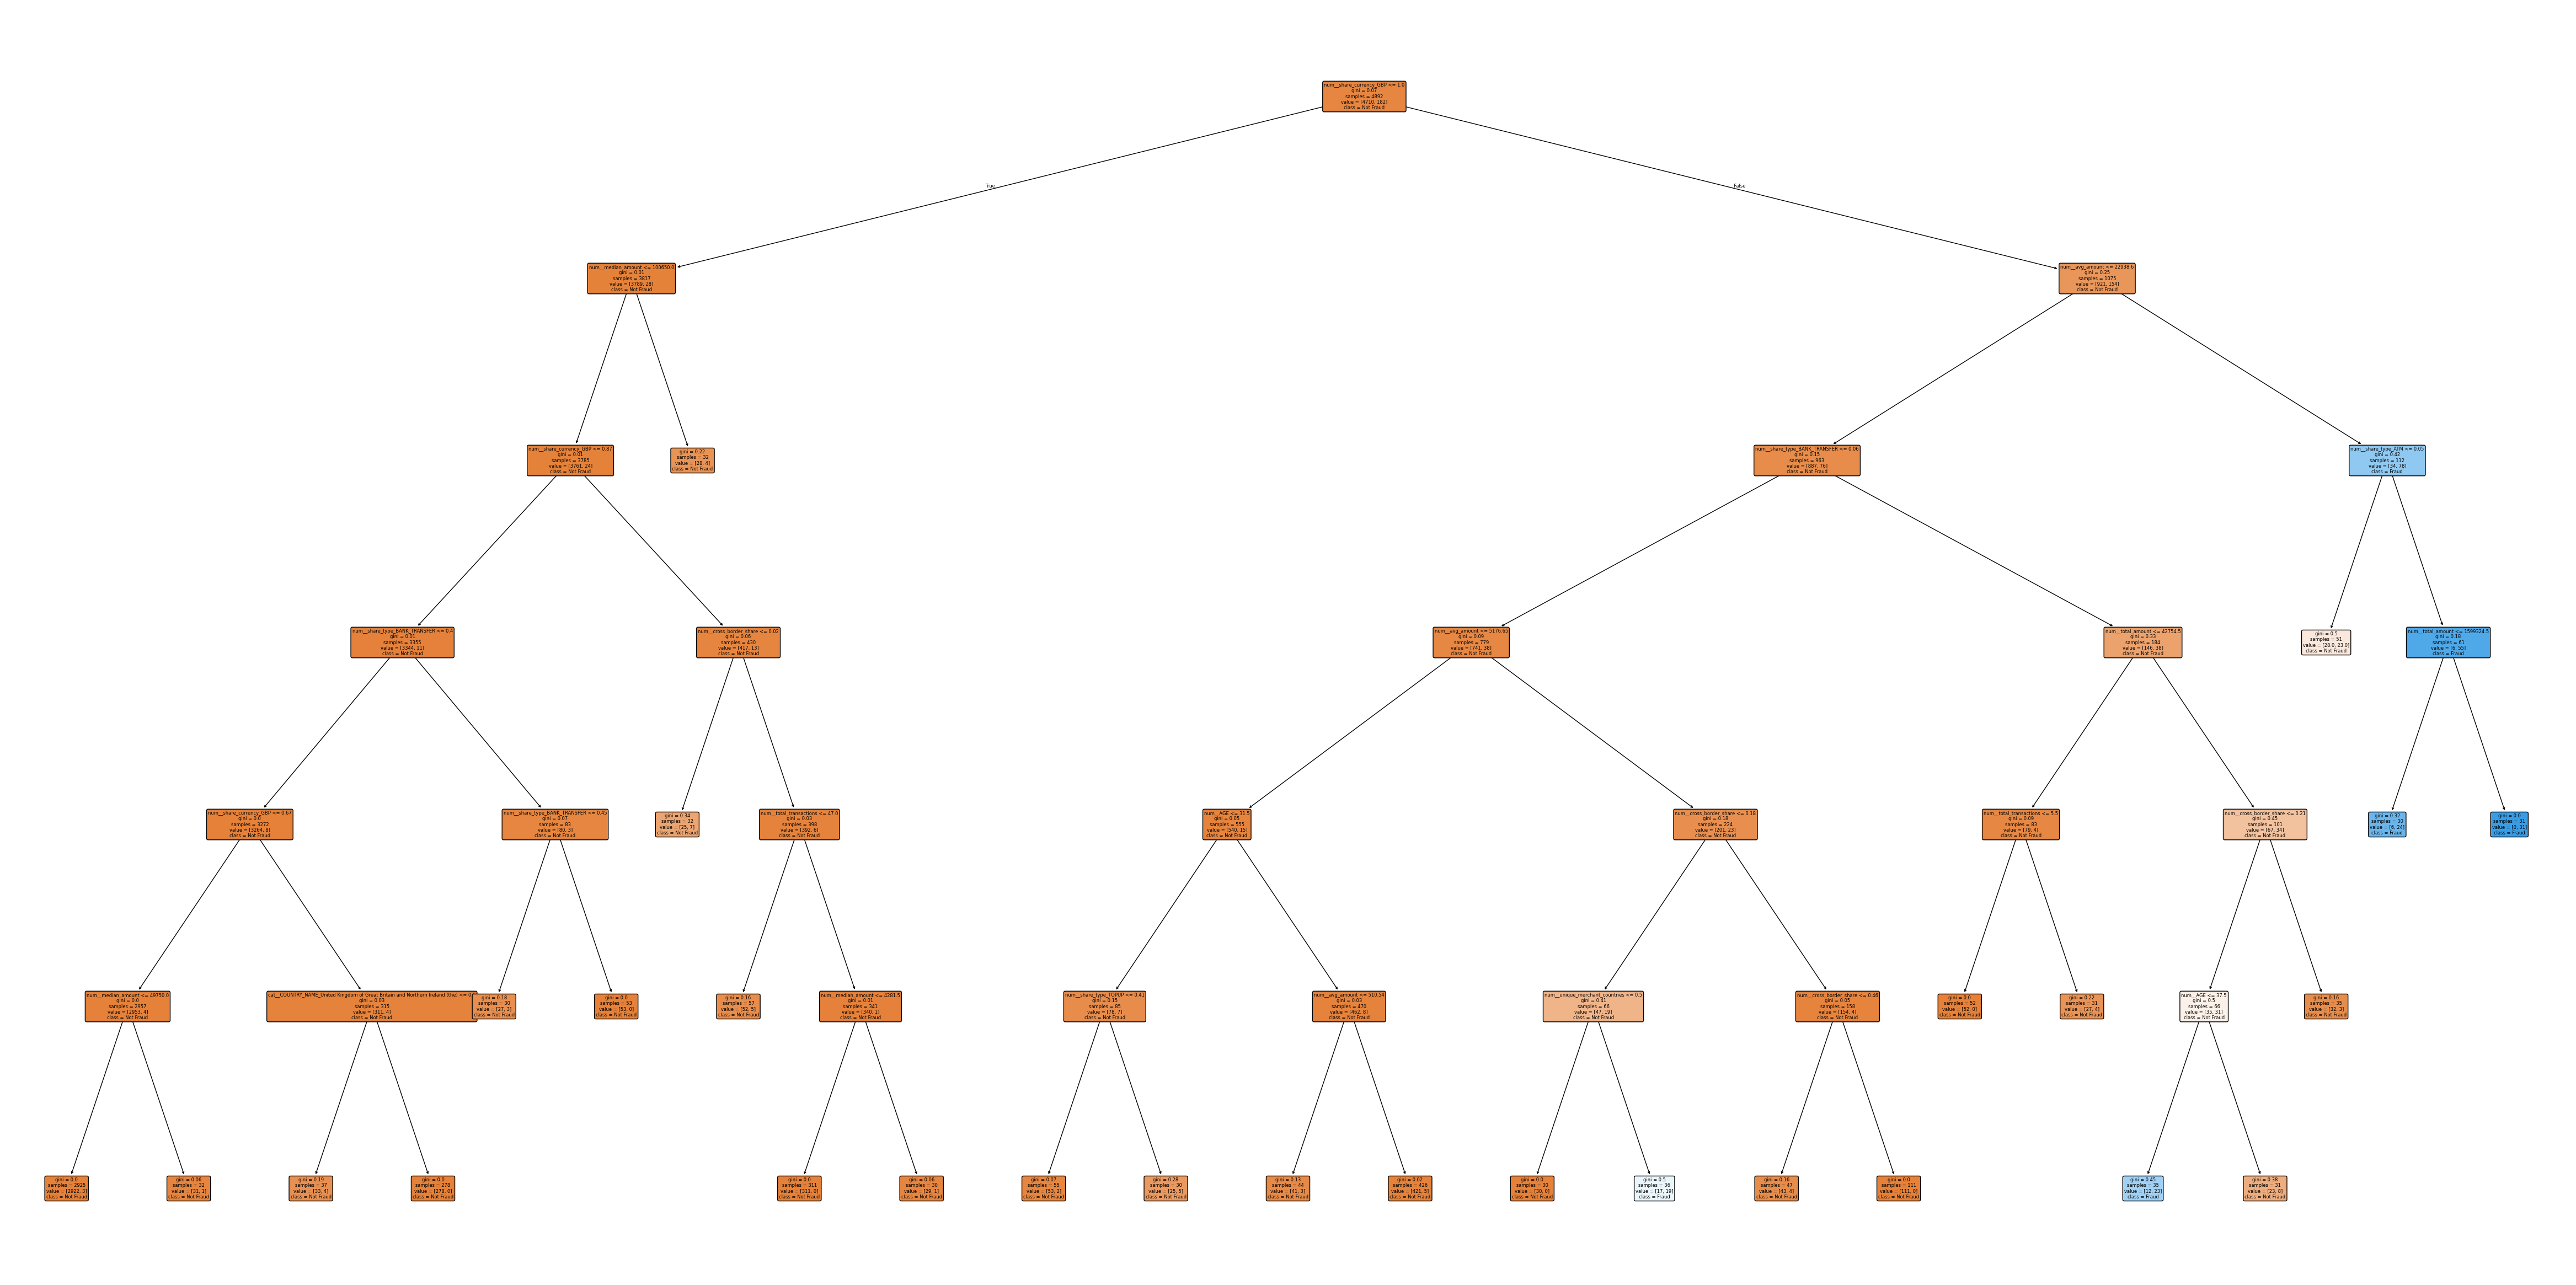

In [107]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_model = pipeline.named_steps["model"]

plt.figure(figsize=(60, 30))

plot_tree(
    tree_model,
    feature_names=encoded_feature_names,
    class_names=["Not Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=6,
    proportion=False,
    precision=2
)

plt.savefig(
    "decision_tree_visual_large.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# Get trained components
preprocessor = pipeline.named_steps["preprocessor"]
tree_model = pipeline.named_steps["model"]

# Transform X_test
X_test_transformed = preprocessor.transform(X_test)

# Assign each transaction to a decision-tree leaf/cluster
leaf_ids = tree_model.apply(X_test_transformed)

# Create cluster dataframe
cluster_df = X_test.copy()
cluster_df["IS_FRAUD"] = y_test.values
cluster_df["cluster_id"] = leaf_ids

# Fraud rate by cluster
cluster_fraud_rate = cluster_df.groupby("cluster_id").agg(
    transactions=("IS_FRAUD", "count"),
    fraud_transactions=("IS_FRAUD", "sum")
).reset_index()

cluster_fraud_rate["fraud_rate_pct"] = (
    cluster_fraud_rate["fraud_transactions"] / cluster_fraud_rate["transactions"] * 100
).round(2)

cluster_fraud_rate = cluster_fraud_rate.sort_values(
    "fraud_rate_pct",
    ascending=False
)

cluster_fraud_rate

,cluster_id,transactions,fraud_transactions,fraud_rate_pct
25,51,3,3,100.00
26,52,16,13,81.25
21,45,14,10,71.43
22,46,8,4,50.00
24,49,19,9,47.37
16,35,18,8,44.44
9,20,12,2,16.67
13,30,20,2,10.00
20,42,13,1,7.69
12,28,14,1,7.14


In [109]:
from sklearn.tree import _tree
import pandas as pd

# Get trained components
preprocessor = pipeline.named_steps["preprocessor"]
tree_model = pipeline.named_steps["model"]

# Transform X_test
X_test_transformed = preprocessor.transform(X_test)

# Get the decision path for each transaction
# This tells us every node each transaction passed through
node_indicator = tree_model.decision_path(X_test_transformed)

# Create test dataframe
node_df = X_test.copy()
node_df["IS_FRAUD"] = y_test.values

# Calculate fraud rate by every node
node_rows = []

for node_id in range(tree_model.tree_.node_count):
    # Get rows that passed through this node
    sample_indices = node_indicator[:, node_id].nonzero()[0]
    
    if len(sample_indices) == 0:
        continue
    
    node_data = node_df.iloc[sample_indices]
    
    node_rows.append({
        "node_id": node_id,
        "transactions": node_data["IS_FRAUD"].count(),
        "fraud_transactions": node_data["IS_FRAUD"].sum(),
        "fraud_rate_pct": (node_data["IS_FRAUD"].mean() * 100).round(2)
    })

node_fraud_rate = pd.DataFrame(node_rows)

def get_node_depths(tree):
    children_left = tree.children_left
    children_right = tree.children_right
    
    node_depths = {}
    
    def recurse(node_id, depth):
        node_depths[node_id] = depth
        
        if children_left[node_id] != _tree.TREE_LEAF:
            recurse(children_left[node_id], depth + 1)
            recurse(children_right[node_id], depth + 1)
    
    recurse(0, 0)
    return node_depths

node_depths = get_node_depths(tree_model.tree_)

node_fraud_rate["depth"] = node_fraud_rate["node_id"].map(node_depths)

encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

def get_all_node_rules(tree_model, feature_names):
    tree_ = tree_model.tree_
    
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]
    
    node_rules = []
    
    def recurse(node_id, rules):
        node_rules.append({
            "node_id": node_id,
            "rules": " AND ".join(rules) if rules else "Full population"
        })
        
        if tree_.feature[node_id] != _tree.TREE_UNDEFINED:
            name = feature_name[node_id]
            threshold = tree_.threshold[node_id]
            
            left_rule = f"{name} <= {threshold:.2f}"
            right_rule = f"{name} > {threshold:.2f}"
            
            recurse(tree_.children_left[node_id], rules + [left_rule])
            recurse(tree_.children_right[node_id], rules + [right_rule])
    
    recurse(0, [])
    return pd.DataFrame(node_rules)

node_rules_df = get_all_node_rules(tree_model, encoded_feature_names)

node_fraud_rate_with_rules = node_fraud_rate.merge(
    node_rules_df,
    on="node_id",
    how="left"
)

node_fraud_rate_with_rules = node_fraud_rate_with_rules.sort_values(
    ["depth", "fraud_rate_pct"],
    ascending=[True, False]
).reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

node_fraud_rate_with_rules.sort_values("fraud_rate_pct", ascending=False).head(50)

,node_id,transactions,fraud_transactions,fraud_rate_pct,depth,rules
13,51,3,3,100.00,4,num__share_currency_GBP > 1.00 AND num__avg_amount > 22938.60 AND num__share_type_ATM > 0.05 AND num__total_amount <= 1599324.50
7,50,19,16,84.21,3,num__share_currency_GBP > 1.00 AND num__avg_amount > 22938.60 AND num__share_type_ATM > 0.05
14,52,16,13,81.25,4,num__share_currency_GBP > 1.00 AND num__avg_amount > 22938.60 AND num__share_type_ATM > 0.05 AND num__total_amount > 1599324.50
37,45,14,10,71.43,6,num__share_currency_GBP > 1.00 AND num__avg_amount <= 22938.60 AND num__share_type_BANK_TRANSFER > 0.06 AND num__total_amount > 42754.50 AND num__cross_border_share <= 0.21 AND num__AGE <= 37.50
3,48,38,25,65.79,2,num__share_currency_GBP > 1.00 AND num__avg_amount > 22938.60
23,44,22,14,63.64,5,num__share_currency_GBP > 1.00 AND num__avg_amount <= 22938.60 AND num__share_type_BANK_TRANSFER > 0.06 AND num__total_amount > 42754.50 AND num__cross_border_share <= 0.21
38,46,8,4,50.00,6,num__share_currency_GBP > 1.00 AND num__avg_amount <= 22938.60 AND num__share_type_BANK_TRANSFER > 0.06 AND num__total_amount > 42754.50 AND num__cross_border_share <= 0.21 AND num__AGE > 37.50
8,49,19,9,47.37,3,num__share_currency_GBP > 1.00 AND num__avg_amount > 22938.60 AND num__share_type_ATM <= 0.05
39,35,18,8,44.44,6,num__share_currency_GBP > 1.00 AND num__avg_amount <= 22938.60 AND num__share_type_BANK_TRANSFER <= 0.06 AND num__avg_amount > 5176.65 AND num__cross_border_share <= 0.18 AND num__unique_merchant_countries > 0.50
15,43,45,15,33.33,4,num__share_currency_GBP > 1.00 AND num__avg_amount <= 22938.60 AND num__share_type_BANK_TRANSFER > 0.06 AND num__total_amount > 42754.50


In [69]:
from sklearn.tree import _tree

tree_model = pipeline.named_steps["model"]
encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

def get_leaf_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]

    leaf_rules = []

    def recurse(node, rules):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_rules = rules + [f"{name} <= {threshold:.2f}"]
            right_rules = rules + [f"{name} > {threshold:.2f}"]

            recurse(tree_.children_left[node], left_rules)
            recurse(tree_.children_right[node], right_rules)
        else:
            leaf_rules.append({
                "cluster_id": node,
                "rules": " AND ".join(rules)
            })

    recurse(0, [])
    return pd.DataFrame(leaf_rules)

leaf_rules_df = get_leaf_rules(tree_model, encoded_feature_names)

leaf_rules_df

,cluster_id,rules
0,3,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
1,4,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
2,6,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
3,7,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
4,10,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
5,11,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
6,13,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
7,14,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...


In [72]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)

cluster_fraud_rate_with_rules = cluster_fraud_rate.merge(
    leaf_rules_df,
    on="cluster_id",
    how="left"
)

cluster_fraud_rate_with_rules = cluster_fraud_rate_with_rules.sort_values(
    "fraud_rate_pct",
    ascending=False
).reset_index(drop=True)

cluster_fraud_rate_with_rules

,cluster_id,transactions,fraud_transactions,fraud_rate_pct,rules
0,11,379,59,15.57,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False <= 0.50 AND cat__COUNTRY_NAME_Germany > 0.50
1,14,5864,853,14.55,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False > 0.50 AND num__AMOUNT > 20486.50
2,7,649,82,12.63,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland > 0.50 AND num__AGE > 43.50
3,4,616,29,4.71,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Norway > 0.50
4,13,58998,2084,3.53,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False > 0.50 AND num__AMOUNT <= 20486.50
5,10,35091,304,0.87,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False <= 0.50 AND cat__COUNTRY_NAME_Germany <= 0.50
6,3,100080,282,0.28,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Norway <= 0.50
7,6,1658,0,0.00,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland > 0.50 AND num__AGE <= 43.50


In [58]:
feature_importance["importance_pct"] = (
    feature_importance["importance"] * 100
).round(2)

feature_importance.head(30)

,feature,importance,importance_pct
14,cat__CURRENCY_GBP,0.604869,60.49
256,cat__CROSS_BORDER_FLAG_False,0.166907,16.69
258,num__AMOUNT,0.063942,6.39
206,cat__MERCHANT_COUNTRY_NAME_Poland,0.054313,5.43
45,cat__COUNTRY_NAME_Germany,0.049133,4.91
259,num__AGE,0.031935,3.19
197,cat__MERCHANT_COUNTRY_NAME_Norway,0.028901,2.89
168,cat__MERCHANT_COUNTRY_NAME_Lao People's Democratic Republic (the),0.000000,0.00
169,cat__MERCHANT_COUNTRY_NAME_Latvia,0.000000,0.00
170,cat__MERCHANT_COUNTRY_NAME_Lebanon,0.000000,0.00


Bonus Challenge: We want to understand who attacks us, not just how much.
Task: Identify the Top 5 Fraudsters in the dataset. A simple ranking by total volume or total
financial loss is insufficient for our risk strategy.
Requirement: Present a Top 5 list that you would hand to the Head of Risk as the highest
priority targets, and strictly justify why these specific users made the cut over others who
might have stolen more.

In [14]:
fraudster_base = df_final.groupby("USER_ID").agg(
    total_transactions=("USER_ID", "count"),
    fraud_transactions=("IS_FRAUD", "sum"),
    total_amount=("AMOUNT", "sum"),
    fraud_amount=("AMOUNT", lambda x: x[df_final.loc[x.index, "IS_FRAUD"]].sum()),
    avg_amount=("AMOUNT", "mean"),
    max_amount=("AMOUNT", "max"),
    unique_types=("TYPE", "nunique"),
    unique_currencies=("CURRENCY", "nunique"),
    unique_merchant_countries=("MERCHANT_COUNTRY_NAME", "nunique"),
    cross_border_transactions=("CROSS_BORDER_FLAG", "sum"),
    kyc_status=("KYC", "first"),
    birth_year=("BIRTH_YEAR", "first"),
    country_name=("COUNTRY_NAME", "first")
).reset_index()

fraudster_base["fraud_rate"] = (
    fraudster_base["fraud_transactions"] / fraudster_base["total_transactions"]
)

fraudster_base["cross_border_rate"] = (
    fraudster_base["cross_border_transactions"] / fraudster_base["total_transactions"]
)

fraudster_base["kyc_passed_flag"] = np.where(
    fraudster_base["kyc_status"] == "PASSED",
    1,
    0
)

fraudster_base = fraudster_base[
    fraudster_base["fraud_transactions"] > 0
].copy()

In [17]:
fraudster_base.sort_values(
    by=["fraud_rate", "fraud_amount", "fraud_transactions"],
    ascending=[False, False, False]
).head(5)

,USER_ID,total_transactions,fraud_transactions,total_amount,fraud_amount,avg_amount,max_amount,unique_types,unique_currencies,unique_merchant_countries,cross_border_transactions,kyc_status,birth_year,country_name,fraud_rate,cross_border_rate,kyc_passed_flag
6842,dc283b17-bbe1-4ae9-a11c-0029d5ae71d9,1029,1029,60986488,60986488,59267.724004,7175831,5,2,11,277,PENDING,1998,United Kingdom of Great Britain and Northern I...,1.0,0.269193,0
1570,310667d1-92c6-4fc7-83f1-55b61773ace5,60,60,13460553,13460553,224342.550000,2788607,4,3,2,2,PASSED,1989,United Kingdom of Great Britain and Northern I...,1.0,0.033333,1
1113,2182c140-9de3-4afc-90c1-cbce1ead4238,14,14,11910750,11910750,850767.857143,2418500,2,3,0,0,PASSED,1976,Spain,1.0,0.000000,1
5725,b8271606-4633-4d8f-8729-a2c8ebb8a49f,340,340,11827642,11827642,34787.182353,500000,5,4,3,7,PASSED,1982,Poland,1.0,0.020588,1
1405,2ba04c04-64a4-48f9-8f50-896f573a0845,200,200,6107270,6107270,30536.350000,192000,5,1,2,23,PASSED,1985,United Kingdom of Great Britain and Northern I...,1.0,0.115000,1


##### Insights in data exploration 

1. There are only null fields in MERCHANT_COUNTRY column
2. There are some exceptions that I needed to threat in dataset to be able to give most accurate result

In [127]:
from pathlib import Path

file_path = Path("fin_crime_data.csv")

with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(f.readline())

USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD

7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False

20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False

0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False

20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False



In [128]:
import csv

with open("fin_crime_data.csv", "r", encoding="utf-8", errors="replace") as f:
    sample = f.read(5000)

sniffer = csv.Sniffer()
dialect = sniffer.sniff(sample)

print("Detected delimiter:", repr(dialect.delimiter))

Detected delimiter: ','


In [154]:
# Create helper columns
df_fraudster = df_final.copy()

df_fraudster["FRAUD_AMOUNT"] = np.where(
    df_fraudster["IS_FRAUD"] == True,
    df_fraudster["AMOUNT"],
    0
)

# User-level fraudster table
fraudster_table = df_fraudster.groupby("USER_ID").agg(
    total_transactions=("USER_ID", "count"),
    fraud_transactions=("IS_FRAUD", "sum"),
    total_amount=("AMOUNT", "sum"),
    fraud_amount=("FRAUD_AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median"),
    max_amount=("AMOUNT", "max"),
    unique_types=("TYPE", "nunique"),
    unique_currencies=("CURRENCY", "nunique"),
    unique_merchant_countries=("MERCHANT_COUNTRY_NAME", "nunique"),
    kyc_status=("KYC", "first"),
    country_name=("COUNTRY_NAME", "first")
).reset_index()

# Keep only users with at least one fraud transaction
fraudster_table = fraudster_table[
    fraudster_table["fraud_transactions"] > 0
].copy()

# Rates within each user
fraudster_table["fraud_rate_pct"] = (
    fraudster_table["fraud_transactions"] /
    fraudster_table["total_transactions"] * 100
).round(2)

fraudster_table["fraud_amount_share_within_user_pct"] = (
    fraudster_table["fraud_amount"] /
    fraudster_table["total_amount"] * 100
).round(2)

# Total references
total_dataset_transactions = len(df_final)
total_dataset_amount = df_final["AMOUNT"].sum()
total_fraud_transactions = df_final["IS_FRAUD"].sum()
total_fraud_amount = df_fraudster["FRAUD_AMOUNT"].sum()
total_fraudster_users = fraudster_table["USER_ID"].nunique()

# Share of total dataset
fraudster_table["share_total_transactions_pct"] = (
    fraudster_table["total_transactions"] /
    total_dataset_transactions * 100
).round(2)

fraudster_table["share_total_amount_pct"] = (
    fraudster_table["total_amount"] /
    total_dataset_amount * 100
).round(2)

# Share of total fraud exposure
fraudster_table["share_fraud_transactions_pct"] = (
    fraudster_table["fraud_transactions"] /
    total_fraud_transactions * 100
).round(2)

fraudster_table["share_fraud_amount_pct"] = (
    fraudster_table["fraud_amount"] /
    total_fraud_amount * 100
).round(2)

# Share of total fraudster users
fraudster_table["share_fraudster_users_pct"] = round(
    1 / total_fraudster_users * 100,
    2
)

fraudster_table["rank_fraud_amount"] = fraudster_table["fraud_amount"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_fraud_transactions"] = fraudster_table["fraud_transactions"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_fraud_rate"] = fraudster_table["fraud_rate_pct"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_total_amount"] = fraudster_table["total_amount"].rank(
    ascending=False,
    method="dense"
)

In [157]:
fraudster_table_view = fraudster_table.sort_values(
    ["fraud_amount", "fraud_transactions", "fraud_rate_pct"],
    ascending=[False, False, False]
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

fraudster_table_view[
    [
        "USER_ID",
        "country_name",
        "kyc_status",
        "total_transactions",
        "share_total_transactions_pct",
        "fraud_transactions",
        "share_fraud_transactions_pct",
        "fraud_rate_pct",
        "total_amount",
        "share_total_amount_pct",
        "fraud_amount",
        "share_fraud_amount_pct",
        "fraud_amount_share_within_user_pct",
        "avg_amount",
        "median_amount",
        "max_amount",
        "unique_types",
        "unique_currencies",
        "unique_merchant_countries",
        "rank_fraud_amount",
        "rank_fraud_transactions",
        "rank_fraud_rate"
    ]
].head(20)

,USER_ID,country_name,kyc_status,total_transactions,share_total_transactions_pct,fraud_transactions,share_fraud_transactions_pct,fraud_rate_pct,total_amount,share_total_amount_pct,fraud_amount,share_fraud_amount_pct,fraud_amount_share_within_user_pct,avg_amount,median_amount,max_amount,unique_types,unique_currencies,unique_merchant_countries,rank_fraud_amount,rank_fraud_transactions,rank_fraud_rate
6842,dc283b17-bbe1-4ae9-a11c-0029d5ae71d9,United Kingdom of Great Britain and Northern Ireland (the),PENDING,1029,0.15,1029,7.08,100.00,60986488,0.28,60986488,14.24,100.00,"59,267.72","1,290.00",7175831,5,2,11,1.00,1.00,1.00
1570,310667d1-92c6-4fc7-83f1-55b61773ace5,United Kingdom of Great Britain and Northern Ireland (the),PASSED,60,0.01,60,0.41,100.00,13460553,0.06,13460553,3.14,100.00,"224,342.55","1,995.00",2788607,4,3,2,2.00,50.00,1.00
1113,2182c140-9de3-4afc-90c1-cbce1ead4238,Spain,PASSED,14,0.00,14,0.10,100.00,11910750,0.05,11910750,2.78,100.00,"850,767.86","487,025.00",2418500,2,3,0,3.00,94.00,1.00
5725,b8271606-4633-4d8f-8729-a2c8ebb8a49f,Poland,PASSED,340,0.05,340,2.34,100.00,11827642,0.05,11827642,2.76,100.00,"34,787.18","4,213.00",500000,5,4,3,4.00,5.00,1.00
1405,2ba04c04-64a4-48f9-8f50-896f573a0845,United Kingdom of Great Britain and Northern Ireland (the),PASSED,200,0.03,200,1.38,100.00,6107270,0.03,6107270,1.43,100.00,"30,536.35","30,000.00",192000,5,1,2,5.00,10.00,1.00
5909,bdab8e60-3375-40b7-98ae-d47ef2ef6bf7,United Kingdom of Great Britain and Northern Ireland (the),PASSED,85,0.01,85,0.58,100.00,5882763,0.03,5882763,1.37,100.00,"69,208.98","11,300.00",1000000,4,2,2,6.00,38.00,1.00
585,11fa06ae-839a-4279-b85e-191f57d0138a,United Kingdom of Great Britain and Northern Ireland (the),PASSED,63,0.01,63,0.43,100.00,5798352,0.03,5798352,1.35,100.00,"92,037.33","49,000.00",500000,4,1,1,7.00,49.00,1.00
393,0bed6203-0ed0-4e40-8f9c-e52ed7dedb6a,United Kingdom of Great Britain and Northern Ireland (the),PASSED,96,0.01,96,0.66,100.00,5388587,0.02,5388587,1.26,100.00,"56,131.11","25,000.00",964000,5,1,1,8.00,33.00,1.00
4981,9fa08d28-fdf0-49d5-a92c-7fb78512a8ab,United Kingdom of Great Britain and Northern Ireland (the),PASSED,72,0.01,72,0.50,100.00,5167877,0.02,5167877,1.21,100.00,"71,776.07","40,832.00",500000,4,2,4,9.00,44.00,1.00
1180,23aeb3e7-c41a-4337-87a8-89d06969a6a4,United Kingdom of Great Britain and Northern Ireland (the),PASSED,162,0.02,162,1.11,100.00,5066593,0.02,5066593,1.18,100.00,"31,275.27","24,500.00",980000,4,1,3,10.00,18.00,1.00


In [158]:
# ============================================================
# Fraudster user-level analysis + amount/country pattern views
# ============================================================

import numpy as np
import pandas as pd

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# ------------------------------------------------------------
# 1. Create helper fraud amount column
# ------------------------------------------------------------

df_fraudster = df_final.copy()

df_fraudster["FRAUD_AMOUNT"] = np.where(
    df_fraudster["IS_FRAUD"] == True,
    df_fraudster["AMOUNT"],
    0
)

# ------------------------------------------------------------
# 2. Country + amount pattern view
# This checks how common each transaction amount is within each country
# and how much fraud is concentrated in that amount-country combination.
# ------------------------------------------------------------

country_amount_view = df_fraudster.groupby(
    ["COUNTRY_NAME", "AMOUNT"],
    dropna=False
).agg(
    country_amount_transactions=("USER_ID", "count"),
    country_amount_users=("USER_ID", "nunique"),
    country_amount_fraud_transactions=("IS_FRAUD", "sum"),
    country_amount_fraud_amount=("FRAUD_AMOUNT", "sum")
).reset_index()

country_totals = df_fraudster.groupby(
    "COUNTRY_NAME",
    dropna=False
).agg(
    country_transactions=("USER_ID", "count"),
    country_fraud_transactions=("IS_FRAUD", "sum"),
    country_total_amount=("AMOUNT", "sum"),
    country_fraud_amount=("FRAUD_AMOUNT", "sum")
).reset_index()

country_amount_view = country_amount_view.merge(
    country_totals,
    on="COUNTRY_NAME",
    how="left"
)

country_amount_view["transaction_share_within_country_pct"] = (
    country_amount_view["country_amount_transactions"] /
    country_amount_view["country_transactions"] * 100
).round(2)

country_amount_view["fraud_transaction_share_within_country_pct"] = (
    country_amount_view["country_amount_fraud_transactions"] /
    country_amount_view["country_fraud_transactions"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

country_amount_view["fraud_amount_share_within_country_pct"] = (
    country_amount_view["country_amount_fraud_amount"] /
    country_amount_view["country_fraud_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

country_amount_view["amount_country_fraud_rate_pct"] = (
    country_amount_view["country_amount_fraud_transactions"] /
    country_amount_view["country_amount_transactions"] * 100
).round(2)

# ------------------------------------------------------------
# 3. Bring country + amount pattern indicators back to transaction level
# ------------------------------------------------------------

df_fraudster_enriched = df_fraudster.merge(
    country_amount_view[
        [
            "COUNTRY_NAME",
            "AMOUNT",
            "transaction_share_within_country_pct",
            "fraud_transaction_share_within_country_pct",
            "fraud_amount_share_within_country_pct",
            "amount_country_fraud_rate_pct"
        ]
    ],
    on=["COUNTRY_NAME", "AMOUNT"],
    how="left"
)

# ------------------------------------------------------------
# 4. User-level fraudster table
# ------------------------------------------------------------

fraudster_table = df_fraudster_enriched.groupby("USER_ID").agg(
    total_transactions=("USER_ID", "count"),
    fraud_transactions=("IS_FRAUD", "sum"),
    total_amount=("AMOUNT", "sum"),
    fraud_amount=("FRAUD_AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median"),
    max_amount=("AMOUNT", "max"),
    unique_types=("TYPE", "nunique"),
    unique_currencies=("CURRENCY", "nunique"),
    unique_merchant_countries=("MERCHANT_COUNTRY_NAME", "nunique"),
    kyc_status=("KYC", "first"),
    country_name=("COUNTRY_NAME", "first"),

    avg_amount_country_transaction_share_pct=("transaction_share_within_country_pct", "mean"),
    max_amount_country_transaction_share_pct=("transaction_share_within_country_pct", "max"),
    avg_amount_country_fraud_tx_share_pct=("fraud_transaction_share_within_country_pct", "mean"),
    max_amount_country_fraud_tx_share_pct=("fraud_transaction_share_within_country_pct", "max"),
    avg_amount_country_fraud_amount_share_pct=("fraud_amount_share_within_country_pct", "mean"),
    max_amount_country_fraud_amount_share_pct=("fraud_amount_share_within_country_pct", "max"),
    avg_amount_country_fraud_rate_pct=("amount_country_fraud_rate_pct", "mean"),
    max_amount_country_fraud_rate_pct=("amount_country_fraud_rate_pct", "max")
).reset_index()

# Keep only users with at least one fraud transaction
fraudster_table = fraudster_table[
    fraudster_table["fraud_transactions"] > 0
].copy()

# ------------------------------------------------------------
# 5. User-level rates
# ------------------------------------------------------------

fraudster_table["fraud_rate_pct"] = (
    fraudster_table["fraud_transactions"] /
    fraudster_table["total_transactions"] * 100
).round(2)

fraudster_table["fraud_amount_share_within_user_pct"] = (
    fraudster_table["fraud_amount"] /
    fraudster_table["total_amount"] * 100
).round(2)

# ------------------------------------------------------------
# 6. Total references
# ------------------------------------------------------------

total_dataset_transactions = len(df_final)
total_dataset_amount = df_final["AMOUNT"].sum()
total_fraud_transactions = df_final["IS_FRAUD"].sum()
total_fraud_amount = df_fraudster["FRAUD_AMOUNT"].sum()
total_fraudster_users = fraudster_table["USER_ID"].nunique()

# ------------------------------------------------------------
# 7. Share of total dataset and total fraud exposure
# ------------------------------------------------------------

fraudster_table["share_total_transactions_pct"] = (
    fraudster_table["total_transactions"] /
    total_dataset_transactions * 100
).round(2)

fraudster_table["share_total_amount_pct"] = (
    fraudster_table["total_amount"] /
    total_dataset_amount * 100
).round(2)

fraudster_table["share_fraud_transactions_pct"] = (
    fraudster_table["fraud_transactions"] /
    total_fraud_transactions * 100
).round(2)

fraudster_table["share_fraud_amount_pct"] = (
    fraudster_table["fraud_amount"] /
    total_fraud_amount * 100
).round(2)

fraudster_table["share_fraudster_users_pct"] = round(
    1 / total_fraudster_users * 100,
    2
)

# ------------------------------------------------------------
# 8. Ranking dimensions
# ------------------------------------------------------------

fraudster_table["rank_fraud_amount"] = fraudster_table["fraud_amount"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_fraud_transactions"] = fraudster_table["fraud_transactions"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_fraud_rate"] = fraudster_table["fraud_rate_pct"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_total_amount"] = fraudster_table["total_amount"].rank(
    ascending=False,
    method="dense"
)

fraudster_table["rank_amount_country_fraud_rate"] = fraudster_table["max_amount_country_fraud_rate_pct"].rank(
    ascending=False,
    method="dense"
)

# ------------------------------------------------------------
# 9. View sorted by fraud amount first
# ------------------------------------------------------------

fraudster_table_view = fraudster_table.sort_values(
    [
        "fraud_amount",
        "fraud_transactions",
        "fraud_rate_pct",
        "max_amount_country_fraud_rate_pct"
    ],
    ascending=[False, False, False, False]
).reset_index(drop=True)

fraudster_table_view[
    [
        "USER_ID",
        "country_name",
        "kyc_status",

        "total_transactions",
        "share_total_transactions_pct",
        "fraud_transactions",
        "share_fraud_transactions_pct",
        "fraud_rate_pct",

        "total_amount",
        "share_total_amount_pct",
        "fraud_amount",
        "share_fraud_amount_pct",
        "fraud_amount_share_within_user_pct",

        "avg_amount",
        "median_amount",
        "max_amount",

        "unique_types",
        "unique_currencies",
        "unique_merchant_countries",

        "avg_amount_country_transaction_share_pct",
        "max_amount_country_transaction_share_pct",
        "avg_amount_country_fraud_tx_share_pct",
        "max_amount_country_fraud_tx_share_pct",
        "avg_amount_country_fraud_amount_share_pct",
        "max_amount_country_fraud_amount_share_pct",
        "avg_amount_country_fraud_rate_pct",
        "max_amount_country_fraud_rate_pct",

        "rank_fraud_amount",
        "rank_fraud_transactions",
        "rank_fraud_rate",
        "rank_total_amount",
        "rank_amount_country_fraud_rate"
    ]
].head(30)

,USER_ID,country_name,kyc_status,total_transactions,share_total_transactions_pct,fraud_transactions,share_fraud_transactions_pct,fraud_rate_pct,total_amount,share_total_amount_pct,fraud_amount,share_fraud_amount_pct,fraud_amount_share_within_user_pct,avg_amount,median_amount,max_amount,unique_types,unique_currencies,unique_merchant_countries,avg_amount_country_transaction_share_pct,max_amount_country_transaction_share_pct,avg_amount_country_fraud_tx_share_pct,max_amount_country_fraud_tx_share_pct,avg_amount_country_fraud_amount_share_pct,max_amount_country_fraud_amount_share_pct,avg_amount_country_fraud_rate_pct,max_amount_country_fraud_rate_pct,rank_fraud_amount,rank_fraud_transactions,rank_fraud_rate,rank_total_amount,rank_amount_country_fraud_rate
0,dc283b17-bbe1-4ae9-a11c-0029d5ae71d9,United Kingdom of Great Britain and Northern Ireland (the),PENDING,1029,0.15,1029,7.08,100.00,60986488,0.28,60986488,14.24,100.00,"59,267.72","1,290.00",7175831,5,2,11,0.74,3.84,1.34,7.57,0.17,2.80,18.64,100.00,1.00,1.00,1.00,1.00,1.00
1,310667d1-92c6-4fc7-83f1-55b61773ace5,United Kingdom of Great Britain and Northern Ireland (the),PASSED,60,0.01,60,0.41,100.00,13460553,0.06,13460553,3.14,100.00,"224,342.55","1,995.00",2788607,4,3,2,0.52,3.53,1.02,7.57,0.73,8.14,18.24,100.00,2.00,50.00,1.00,2.00,1.00
2,2182c140-9de3-4afc-90c1-cbce1ead4238,Spain,PASSED,14,0.00,14,0.10,100.00,11910750,0.05,11910750,2.78,100.00,"850,767.86","487,025.00",2418500,2,3,0,0.02,0.09,0.73,1.27,4.84,13.09,83.16,100.00,3.00,94.00,1.00,3.00,1.00
3,b8271606-4633-4d8f-8729-a2c8ebb8a49f,Poland,PASSED,340,0.05,340,2.34,100.00,11827642,0.05,11827642,2.76,100.00,"34,787.18","4,213.00",500000,5,4,3,0.34,5.26,0.78,3.17,0.75,13.11,40.13,100.00,4.00,5.00,1.00,4.00,1.00
4,2ba04c04-64a4-48f9-8f50-896f573a0845,United Kingdom of Great Britain and Northern Ireland (the),PASSED,200,0.03,200,1.38,100.00,6107270,0.03,6107270,1.43,100.00,"30,536.35","30,000.00",192000,5,1,2,0.61,3.84,1.55,7.57,1.62,8.14,11.97,41.67,5.00,10.00,1.00,5.00,15.00
5,bdab8e60-3375-40b7-98ae-d47ef2ef6bf7,United Kingdom of Great Britain and Northern Ireland (the),PASSED,85,0.01,85,0.58,100.00,5882763,0.03,5882763,1.37,100.00,"69,208.98","11,300.00",1000000,4,2,2,0.61,3.53,1.39,7.57,1.23,8.14,16.07,100.00,6.00,38.00,1.00,6.00,1.00
6,11fa06ae-839a-4279-b85e-191f57d0138a,United Kingdom of Great Britain and Northern Ireland (the),PASSED,63,0.01,63,0.43,100.00,5798352,0.03,5798352,1.35,100.00,"92,037.33","49,000.00",500000,4,1,1,0.41,3.84,1.15,7.57,1.59,8.14,19.85,100.00,7.00,49.00,1.00,7.00,1.00
7,0bed6203-0ed0-4e40-8f9c-e52ed7dedb6a,United Kingdom of Great Britain and Northern Ireland (the),PASSED,96,0.01,96,0.66,100.00,5388587,0.02,5388587,1.26,100.00,"56,131.11","25,000.00",964000,5,1,1,1.13,3.84,3.04,7.57,3.37,8.14,13.20,100.00,8.00,33.00,1.00,8.00,1.00
8,9fa08d28-fdf0-49d5-a92c-7fb78512a8ab,United Kingdom of Great Britain and Northern Ireland (the),PASSED,72,0.01,72,0.50,100.00,5167877,0.02,5167877,1.21,100.00,"71,776.07","40,832.00",500000,4,2,4,0.73,3.84,1.67,7.57,1.46,8.14,24.88,100.00,9.00,44.00,1.00,9.00,1.00
9,23aeb3e7-c41a-4337-87a8-89d06969a6a4,United Kingdom of Great Britain and Northern Ireland (the),PASSED,162,0.02,162,1.11,100.00,5066593,0.02,5066593,1.18,100.00,"31,275.27","24,500.00",980000,4,1,3,0.82,3.84,1.91,7.57,1.62,8.14,12.97,100.00,10.00,18.00,1.00,10.00,1.00


In [187]:
# ============================================================
# User-level fraudster table with total share and country share
# ============================================================

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# ------------------------------------------------------------
# 1. Copy dataset and create fraud amount helper
# ------------------------------------------------------------

df_fraudster = df_final.copy()

df_fraudster["FRAUD_AMOUNT"] = np.where(
    df_fraudster["IS_FRAUD"] == True,
    df_fraudster["AMOUNT"],
    0
)

df_fraudster["ATM_TRANSACTION"] = np.where(
    df_fraudster["TYPE"] == "ATM",
    1,
    0
)

df_fraudster["BANK_TRANSFER_TRANSACTION"] = np.where(
    df_fraudster["TYPE"] == "BANK_TRANSFER",
    1,
    0
)

df_fraudster["ATM_AMOUNT"] = np.where(
    df_fraudster["TYPE"] == "ATM",
    df_fraudster["AMOUNT"],
    0
)

df_fraudster["BANK_TRANSFER_AMOUNT"] = np.where(
    df_fraudster["TYPE"] == "BANK_TRANSFER",
    df_fraudster["AMOUNT"],
    0
)

# ------------------------------------------------------------
# 2. Country-level totals to use as country denominators
# ------------------------------------------------------------

country_totals = df_fraudster.groupby("COUNTRY_NAME", dropna=False).agg(
    country_transactions=("USER_ID", "count"),
    country_fraud_transactions=("IS_FRAUD", "sum"),
    country_amount=("AMOUNT", "sum"),
    country_fraud_amount=("FRAUD_AMOUNT", "sum"),
    country_unique_users=("USER_ID", "nunique"),
    country_fraudster_users=(
        "USER_ID",
        lambda x: df_fraudster.loc[x.index][df_fraudster.loc[x.index, "IS_FRAUD"]]["USER_ID"].nunique()
    )
).reset_index()

# ------------------------------------------------------------
# 3. Total dataset denominators
# ------------------------------------------------------------

total_transactions = len(df_fraudster)
total_fraud_transactions = df_fraudster["IS_FRAUD"].sum()
total_amount = df_fraudster["AMOUNT"].sum()
total_fraud_amount = df_fraudster["FRAUD_AMOUNT"].sum()
total_unique_users = df_fraudster["USER_ID"].nunique()
total_fraudster_users = df_fraudster.loc[df_fraudster["IS_FRAUD"], "USER_ID"].nunique()

# ------------------------------------------------------------
# 4. User-level fraudster table
# ------------------------------------------------------------

fraudster_table = df_fraudster.groupby("USER_ID").agg(
    country_name=("COUNTRY_NAME", "first"),
    kyc_status=("KYC", "first"),

    total_transactions=("USER_ID", "count"),
    fraud_transactions=("IS_FRAUD", "sum"),
    atm_transactions=("ATM_TRANSACTION", "sum"),
    bank_transfer_transactions=("BANK_TRANSFER_TRANSACTION", "sum"),
    atm_amount=("ATM_AMOUNT", "sum"),
    bank_transfer_amount=("BANK_TRANSFER_AMOUNT", "sum"),

    total_amount=("AMOUNT", "sum"),
    fraud_amount=("FRAUD_AMOUNT", "sum"),

    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median"),
    max_amount=("AMOUNT", "max"),

    unique_types=("TYPE", "nunique"),
    unique_currencies=("CURRENCY", "nunique"),
    unique_merchant_countries=("MERCHANT_COUNTRY_NAME", "nunique")
).reset_index()

# Keep only users with at least one fraud transaction
fraudster_table = fraudster_table[
    fraudster_table["fraud_transactions"] > 0
].copy()

# Since this is user-level, each row represents one user
fraudster_table["unique_users"] = 1
fraudster_table["fraudster_users"] = 1

# ------------------------------------------------------------
# 5. Merge country denominators into user-level table
# ------------------------------------------------------------

fraudster_table = fraudster_table.merge(
    country_totals,
    left_on="country_name",
    right_on="COUNTRY_NAME",
    how="left"
)

fraudster_table = fraudster_table.drop(columns=["COUNTRY_NAME"])

# ------------------------------------------------------------
# 6. User-level internal rates
# ------------------------------------------------------------

fraudster_table["fraud_rate_pct"] = (
    fraudster_table["fraud_transactions"] /
    fraudster_table["total_transactions"] * 100
).round(2)

fraudster_table["fraud_amount_share_within_user_pct"] = (
    fraudster_table["fraud_amount"] /
    fraudster_table["total_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["atm_transaction_share_pct"] = (
    fraudster_table["atm_transactions"] /
    fraudster_table["total_transactions"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["bank_transfer_transaction_share_pct"] = (
    fraudster_table["bank_transfer_transactions"] /
    fraudster_table["total_transactions"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["atm_amount_share_pct"] = (
    fraudster_table["atm_amount"] /
    fraudster_table["total_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["bank_transfer_amount_share_pct"] = (
    fraudster_table["bank_transfer_amount"] /
    fraudster_table["total_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# ------------------------------------------------------------
# 7. Share vs total dataset
# ------------------------------------------------------------

fraudster_table["share_total_transactions_pct"] = (
    fraudster_table["total_transactions"] /
    total_transactions * 100
).round(2)

fraudster_table["share_total_fraud_transactions_pct"] = (
    fraudster_table["fraud_transactions"] /
    total_fraud_transactions * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_total_amount_pct"] = (
    fraudster_table["total_amount"] /
    total_amount * 100
).round(2)

fraudster_table["share_total_fraud_amount_pct"] = (
    fraudster_table["fraud_amount"] /
    total_fraud_amount * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_total_unique_users_pct"] = (
    fraudster_table["unique_users"] /
    total_unique_users * 100
).round(2)

fraudster_table["share_total_fraudster_users_pct"] = (
    fraudster_table["fraudster_users"] /
    total_fraudster_users * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# ------------------------------------------------------------
# 8. Share vs user's country
# ------------------------------------------------------------

fraudster_table["share_country_transactions_pct"] = (
    fraudster_table["total_transactions"] /
    fraudster_table["country_transactions"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_country_fraud_transactions_pct"] = (
    fraudster_table["fraud_transactions"] /
    fraudster_table["country_fraud_transactions"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_country_amount_pct"] = (
    fraudster_table["total_amount"] /
    fraudster_table["country_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_country_fraud_amount_pct"] = (
    fraudster_table["fraud_amount"] /
    fraudster_table["country_fraud_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_country_unique_users_pct"] = (
    fraudster_table["unique_users"] /
    fraudster_table["country_unique_users"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

fraudster_table["share_country_fraudster_users_pct"] = (
    fraudster_table["fraudster_users"] /
    fraudster_table["country_fraudster_users"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# ------------------------------------------------------------
# 9. Global ranks
# ------------------------------------------------------------

fraudster_table["rank_global_fraud_amount"] = fraudster_table["fraud_amount"].rank(
    ascending=False,
    method="dense"
).astype(int)

fraudster_table["rank_global_fraud_transactions"] = fraudster_table["fraud_transactions"].rank(
    ascending=False,
    method="dense"
).astype(int)

# ------------------------------------------------------------
# 10. Country ranks
# ------------------------------------------------------------

fraudster_table["rank_country_fraud_amount"] = (
    fraudster_table
    .groupby("country_name")["fraud_amount"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

fraudster_table["rank_country_fraud_transactions"] = (
    fraudster_table
    .groupby("country_name")["fraud_transactions"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# Max rank / number of ranked fraudster positions inside each country
fraudster_table["max_country_fraud_amount_rank"] = (
    fraudster_table
    .groupby("country_name")["rank_country_fraud_amount"]
    .transform("max")
    .astype(int)
)

fraudster_table["max_country_fraud_transactions_rank"] = (
    fraudster_table
    .groupby("country_name")["rank_country_fraud_transactions"]
    .transform("max")
    .astype(int)
)

# Optional readable rank format
fraudster_table["country_fraud_amount_rank_position"] = (
    fraudster_table["rank_country_fraud_amount"].astype(str) +
    " / " +
    fraudster_table["max_country_fraud_amount_rank"].astype(str)
)

fraudster_table["country_fraud_transactions_rank_position"] = (
    fraudster_table["rank_country_fraud_transactions"].astype(str) +
    " / " +
    fraudster_table["max_country_fraud_transactions_rank"].astype(str)
)

fraudster_table["highest_cashout_amount_share_pct"] = fraudster_table[
    ["atm_amount_share_pct", "bank_transfer_amount_share_pct"]
].max(axis=1)

fraudster_table["cashout_amount"] = (
    fraudster_table["atm_amount"] +
    fraudster_table["bank_transfer_amount"]
)

# Cash-out amount share over total amount
fraudster_table["cashout_amount_share_pct"] = (
    fraudster_table["cashout_amount"] /
    fraudster_table["total_amount"] * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# ------------------------------------------------------------
# 11. Final analytical view
# ------------------------------------------------------------

fraudster_table_view = fraudster_table.sort_values(
    [
        "cashout_amount",
        "cashout_amount_share_pct",
        "rank_country_fraud_amount",
        "rank_global_fraud_amount"
        #"fraud_amount",
        #"fraud_transactions",
        #"fraud_rate_pct"
    ],
    ascending=[False, False, True, True]
).reset_index(drop=True)

fraudster_table_view = fraudster_table_view[
    [
        "USER_ID",
        "country_name",
        "kyc_status",

        "total_transactions",
        "fraud_transactions",
        #"fraud_rate_pct",

        "total_amount",
        "fraud_amount",
        #"fraud_amount_share_within_user_pct",

        #"unique_users",
        #"fraudster_users",

        #"share_total_transactions_pct",
        #"share_country_transactions_pct",

        #"share_total_fraud_transactions_pct",
        #"share_country_fraud_transactions_pct",

        #"share_total_amount_pct",
        #"share_country_amount_pct",

        #"share_total_fraud_amount_pct",
        #"share_country_fraud_amount_pct",

        #"share_total_unique_users_pct",
        #"share_country_unique_users_pct",

        #"share_total_fraudster_users_pct",
        #"share_country_fraudster_users_pct",

        "cashout_amount",
        "cashout_amount_share_pct",

        "rank_global_fraud_amount",
        #"rank_country_fraud_amount",
        #"max_country_fraud_amount_rank",
        "country_fraud_amount_rank_position",

        "rank_global_fraud_transactions",
        #"rank_country_fraud_transactions",
        #"max_country_fraud_transactions_rank",
        "country_fraud_transactions_rank_position",

        "avg_amount"
        #"median_amount",
        #"max_amount",

        #"unique_types",
        #"unique_currencies",
        #"unique_merchant_countries",

        #"atm_transactions",
        #"atm_transaction_share_pct",
        #"atm_amount",
        #"atm_amount_share_pct",

        #"bank_transfer_transactions",
        #"bank_transfer_transaction_share_pct",
        #"bank_transfer_amount",
        #"bank_transfer_amount_share_pct",
    ]
]

fraudster_table_view.head(50)

,USER_ID,country_name,kyc_status,total_transactions,fraud_transactions,total_amount,fraud_amount,cashout_amount,cashout_amount_share_pct,rank_global_fraud_amount,country_fraud_amount_rank_position,rank_global_fraud_transactions,country_fraud_transactions_rank_position,avg_amount
0,2182c140-9de3-4afc-90c1-cbce1ead4238,Spain,PASSED,14,14,11910750,11910750,9806700,82.33,3,1 / 3,94,3 / 3,"850,767.86"
1,310667d1-92c6-4fc7-83f1-55b61773ace5,United Kingdom of Great Britain and Northern Ireland (the),PASSED,60,60,13460553,13460553,7496731,55.69,2,2 / 268,50,46 / 103,"224,342.55"
2,b8271606-4633-4d8f-8729-a2c8ebb8a49f,Poland,PASSED,340,340,11827642,11827642,6993392,59.13,4,1 / 2,5,1 / 2,"34,787.18"
3,7e14fe6d-3084-492b-a6ac-7989d37ea887,United Kingdom of Great Britain and Northern Ireland (the),PASSED,134,134,3992489,3992489,2794300,69.99,25,20 / 268,24,21 / 103,"29,794.69"
4,bdab8e60-3375-40b7-98ae-d47ef2ef6bf7,United Kingdom of Great Britain and Northern Ireland (the),PASSED,85,85,5882763,5882763,2757068,46.87,6,4 / 268,38,34 / 103,"69,208.98"
5,0bed6203-0ed0-4e40-8f9c-e52ed7dedb6a,United Kingdom of Great Britain and Northern Ireland (the),PASSED,96,96,5388587,5388587,2595100,48.16,8,6 / 268,33,29 / 103,"56,131.11"
6,23aeb3e7-c41a-4337-87a8-89d06969a6a4,United Kingdom of Great Britain and Northern Ireland (the),PASSED,162,162,5066593,5066593,2568492,50.69,10,8 / 268,18,15 / 103,"31,275.27"
7,40a70d7d-447d-426c-872e-012658b2b98c,United Kingdom of Great Britain and Northern Ireland (the),PASSED,53,53,4801988,4801988,2479000,51.62,14,11 / 268,56,52 / 103,"90,603.55"
8,840a2f6a-b344-4e6b-84fe-ff27531f3125,Poland,FAILED,7,7,4947300,4947300,2472500,49.98,12,2 / 2,101,2 / 2,"706,757.14"
9,4f41a015-5205-467d-98d6-a90d343e8afb,United Kingdom of Great Britain and Northern Ireland (the),PASSED,51,51,4598174,4598174,2437000,53.00,17,14 / 268,58,54 / 103,"90,160.27"
